In [1]:
!pip install scikit-bio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 31.9 MB/s eta 0:00:00


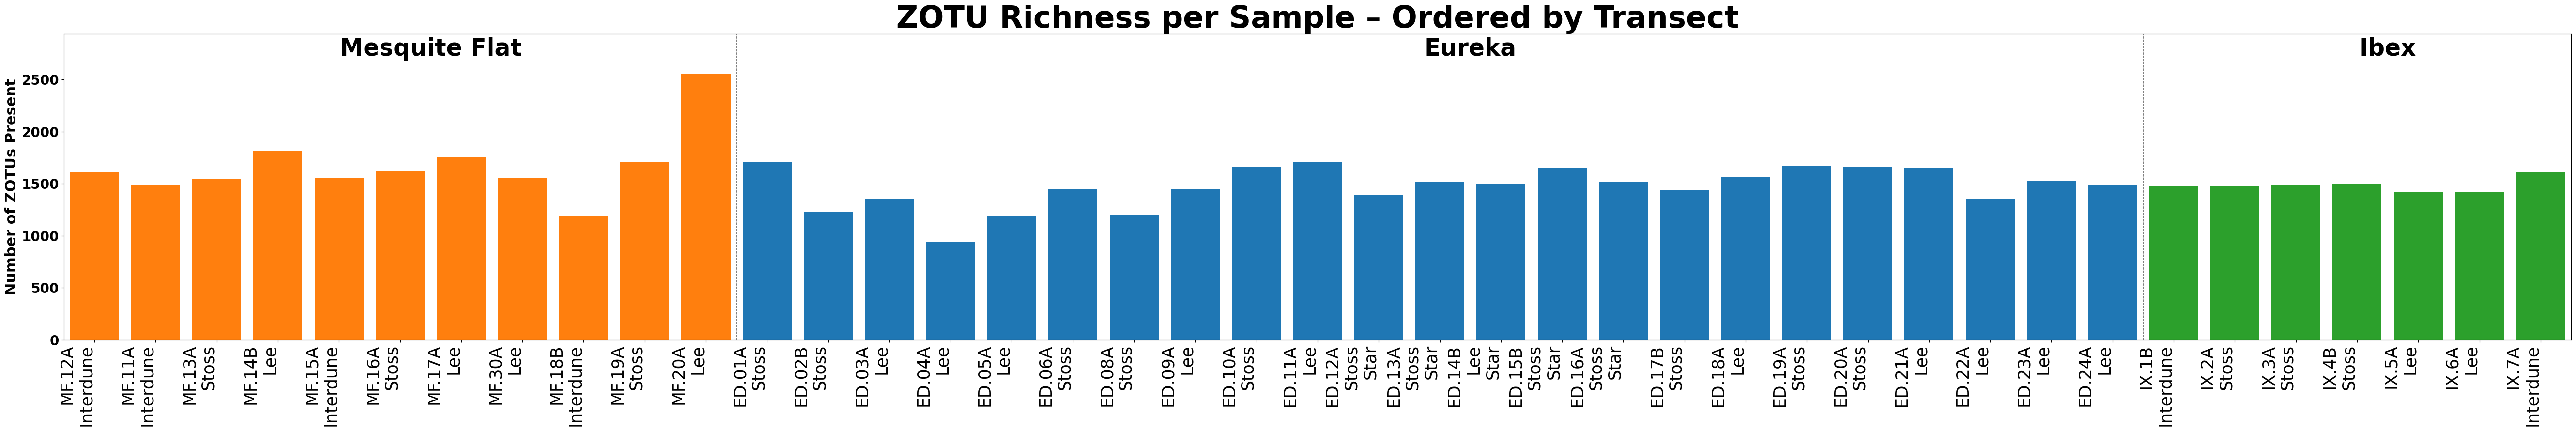

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# ───────────────────────────────────────
# 0″  DEFINE YOUR TRANSECTS  (edit order here if desired)
# ───────────────────────────────────────
#mesquite_north = ["MF.33A","MF.4B","MF.5B","MF.6B","MF.7B","MF.8B",MF.27B]
mesquite= [
    "MF.12A","MF.11A","MF.13A","MF.14B","MF.15A",
    "MF.16A","MF.17A","MF.30A","MF.18B","MF.19A","MF.20A"
]
eumod_transect = [
    "ED.01A","ED.02B","ED.03A","ED.04A","ED.05A","ED.06A","ED.08A",
    "ED.09A","ED.10A","ED.11A","ED.12A","ED.13A","ED.14B","ED.15B",
    "ED.16A","ED.17B","ED.18A","ED.19A","ED.20A","ED.21A",
    "ED.22A","ED.23A","ED.24A"
]
ibex_transect = [
    "IX.1B","IX.2A","IX.3A","IX.4B","IX.5A","IX.6A","IX.7A"
]

transects_ordered = [
#    ("Mesquite North", mesquite_north, "tab:red"),
    ("Mesquite Flat", mesquite, "tab:orange"),
    ("Eureka",         eumod_transect, "tab:blue"),
    ("Ibex",           ibex_transect,   "tab:green")
]

# ───────────────────────────────────────
# 1″  LOAD COUNT TABLE  (row-0 = anatomy, row-1 = header)
# ───────────────────────────────────────
path = "/content/zotutab_decontam_Final.csv"
raw  = pd.read_csv(path, header=None)

anatomy_row = raw.iloc[0]
header_row  = raw.iloc[1]

df = raw.iloc[2:].copy()
df.columns = header_row
df.reset_index(drop=True, inplace=True)

sample_cols = df.columns[1:-7]                       # exclude Zotu + taxonomy
df[sample_cols] = df[sample_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# ZOTU richness per sample
zotu_rich = (df[sample_cols] > 0).astype(int).sum(axis=0)

# Helper function to format anatomy labels
def _format_anatomy_label(label):
    if isinstance(label, str):
        label = label.replace(', Depth', '\nDepth')
        label = label.replace('_Depth', '\nDepth')
        label = label.replace(', ', '\n')
    return label

# label map: "Sample\nAnatomy"
label_map = {
    s: f"{s}\n{_format_anatomy_label(anatomy_row[df.columns.get_loc(s)])}"
    for s in sample_cols
}

# ───────────────────────────────────────
# 2″  BUILD ORDERED LIST OF SAMPLES & COUNTS
# ───────────────────────────────────────
ordered_samples = []
bar_colors      = []
section_bounds  = []          # to draw separator lines

for name, sample_list, color in transects_ordered:
    keep = [s for s in sample_list if s in zotu_rich.index]
    ordered_samples.extend(keep)
    bar_colors.extend([color] * len(keep))
    section_bounds.append(len(ordered_samples))      # boundary after this block

counts  = zotu_rich[ordered_samples]
labels  = [label_map[s] for s in ordered_samples]

# ───────────────────────────────────────
# 3″  PLOT
# ───────────────────────────────────────
plt.figure(figsize=(max(len(labels)*1.3, 19), 9))

plt.bar(range(len(counts)), counts.values, color=bar_colors)

# vertical separators between transects
for bound in section_bounds[:-1]:
    plt.axvline(bound - 0.5, color='gray', linestyle='--', linewidth=0.9)

# add group labels above
midpoints = [section_bounds[0]/2]
for i in range(1, len(section_bounds)):
    midpoints.append((section_bounds[i-1] + section_bounds[i]) / 2)

for midpoint, (name, _, _) in zip(midpoints, transects_ordered):
    plt.text(midpoint, max(counts)*1.05, name, ha='center', va='bottom', fontsize=35, weight='bold')

plt.xticks(range(len(labels)), labels, rotation=90, ha='right', fontsize=25) # Adjusted fontsize to 10
plt.yticks(fontsize=20, fontweight='bold') # Added to increase y-axis label size
plt.ylabel("Number of ZOTUs Present",fontsize= '22', fontweight='bold')
plt.title("ZOTU Richness per Sample – Ordered by Transect",fontsize= '45', fontweight='bold')
plt.ylim(0, max(counts)*1.15)
plt.xlim(-0.5, len(labels) - 0.5)
plt.tight_layout()
plt.show()

### Minimum and Maximum ZOTU Richness by Transect

In [3]:
#GET TRANSECT DIFFERENCES FROM CSV
import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2

# ============================
# LOAD COORDINATE FILE
# ============================
coord_path = "/content/DEVA_Sample_Info.csv"
coords_raw = pd.read_csv(coord_path)

# clean sample names — convert dash to dot to match OTU table
def parse_sample_name(full_name):
    full_name = str(full_name).strip()
    parts     = full_name.split()
    code      = parts[-1]
    return code.replace("-", ".")

coords_raw["SampleID"] = coords_raw["Sample Name:"].apply(
    parse_sample_name)

# clean coordinates
coords_raw["Lat"] = pd.to_numeric(
    coords_raw["Latitude (°N)"],  errors="coerce")
coords_raw["Lon"] = pd.to_numeric(
    coords_raw["Longitude (°W)"], errors="coerce")

# longitude stored as positive W — make negative
coords_raw["Lon"] = coords_raw["Lon"].apply(
    lambda x: -abs(x) if pd.notna(x) else x)

# ============================
# CHECK FOR DUPLICATES
# ============================
print("All parsed sample IDs:")
print(coords_raw[["Sample Name:", "SampleID",
                   "Lat", "Lon"]].to_string())

dupes = coords_raw["SampleID"][
    coords_raw["SampleID"].duplicated()].tolist()
print(f"\nDuplicate SampleIDs: {dupes}")

# ============================
# KEEP FIRST OCCURRENCE
# drop duplicates before building map
# ============================
coords_clean = coords_raw.dropna(
    subset=["Lat", "Lon"]).drop_duplicates(
    subset="SampleID", keep="first")

coord_map = coords_clean.set_index("SampleID")[
    ["Lat", "Lon"]].to_dict(orient="index")

print(f"\nCoordinates loaded for {len(coord_map)} unique samples")

# spot check
print("\nSpot check:")
for s in ["MF.4B", "MF.12A", "ED.01A", "IX.1B"]:
    print(f"  {s}: {coord_map.get(s, 'MISSING')}")

# ============================
# HAVERSINE DISTANCE FUNCTION
# returns distance in metres
# ============================
def haversine_m(lat1, lon1, lat2, lon2):
    R    = 6371000
    phi1 = radians(lat1)
    phi2 = radians(lat2)
    dphi = radians(lat2 - lat1)
    dlam = radians(lon2 - lon1)
    a    = (sin(dphi/2)**2 +
            cos(phi1) * cos(phi2) * sin(dlam/2)**2)
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# ============================
# TEST DISTANCE CALCULATION
# ============================
print("\nDistance test — first to last Mesquite sample:")
mesquite = [
    "MF.12A","MF.11A","MF.13A","MF.14B","MF.15A","MF.31B",
    "MF.16A","MF.30A","MF.17A","MF.18B","MF.19A","MF.20A"
]

anchor = coord_map.get("MF.12A")
if anchor:
    for s in mesquite:
        c = coord_map.get(s)
        if c:
            d = haversine_m(anchor["Lat"], anchor["Lon"],
                            c["Lat"], c["Lon"])
            print(f"  {s}: {d:.1f} m")
        else:
            print(f"  {s}: MISSING coords")

All parsed sample IDs:
                  Sample Name: SampleID        Lat        Lon
0    MESQUITE FLATS SAND MF-4B    MF.4B  36.616170 -117.11751
1    MESQUITE FLATS SAND MF-5B    MF.5B  36.614740 -117.11369
2    MESQUITE FLATS SAND MF-6B    MF.6B  36.614722 -117.11330
3    MESQUITE FLATS SAND MF-7B    MF.7B  36.613910 -117.11299
4    MESQUITE FLATS SAND MF-8B    MF.8B  36.613910 -117.11299
5   MESQUITE FLATS SAND MF-11A   MF.11A  36.615590 -117.12206
6   MESQUITE FLATS SAND MF-12A   MF.12A  36.615590 -117.12206
7   MESQUITE FLATS SAND MF-13A   MF.13A  36.614190 -117.12077
8   MESQUITE FLATS SAND MF-14B   MF.14B  36.613910 -117.12043
9   MESQUITE FLATS SAND MF-15A   MF.15A  36.613540 -117.12106
10  MESQUITE FLATS SAND MF-16A   MF.16A  36.612890 -117.11925
11  MESQUITE FLATS SAND MF-17A   MF.17A  36.612530 -117.11896
12  MESQUITE FLATS SAND MF-18B   MF.18B  36.612180 -117.11875
13  MESQUITE FLATS SAND MF-19A   MF.19A  36.612100 -117.11831
14  MESQUITE FLATS SAND MF-20A   MF.20A  36.611

Prokaryotic ZOTUs: 6014
Alpha diversity computed for 52 samples


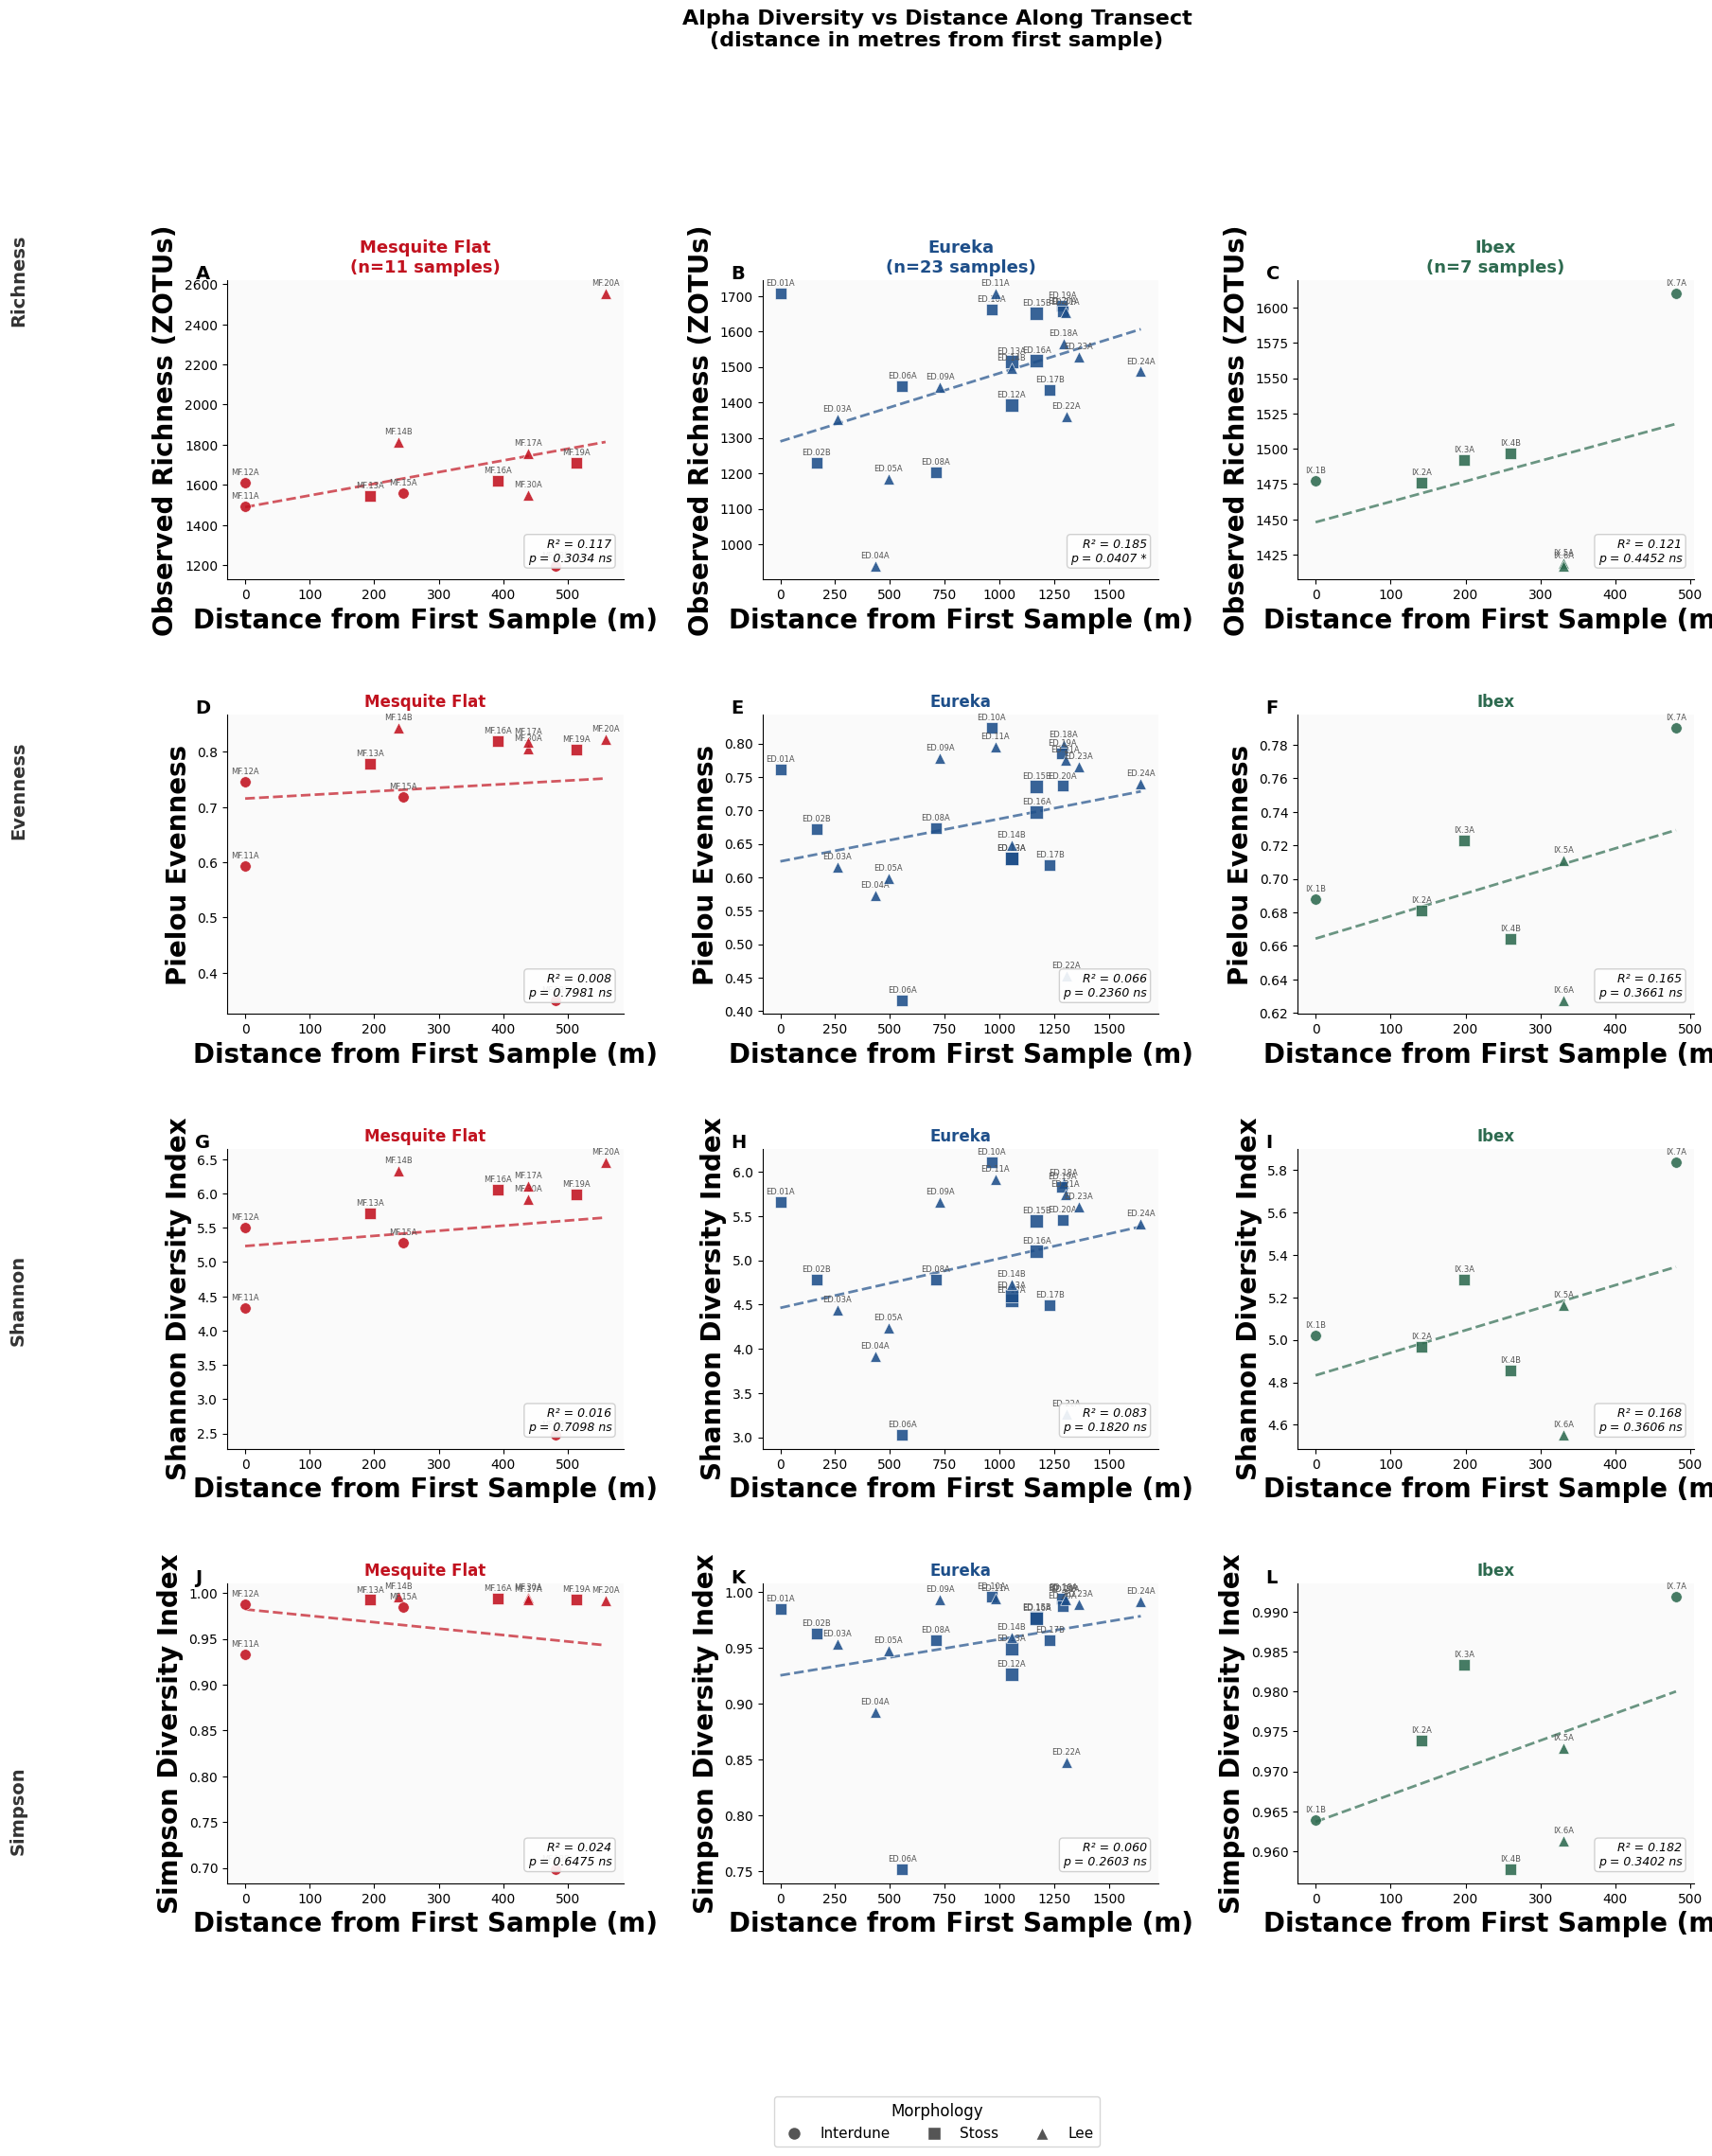

In [4]:
#ALPHA DIVERSITY BY TRANSECT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ============================
# LOAD COUNT FILE
# use raw counts not relative abundance for alpha diversity
# ============================
path = "/content/zotutab_decontam_Final.csv"
raw  = pd.read_csv(path, header=None)

anatomy_row = raw.iloc[0]
header_row  = raw.iloc[1]

df = raw.iloc[2:].copy()
df.columns = header_row
df.reset_index(drop=True, inplace=True)

tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]
zotu_col = df.columns[0]

sample_cols = [c for c in df.columns
               if c not in tax_cols
               and c != zotu_col
               and "Blank" not in str(c)]

df[sample_cols] = df[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df["Domain"] = df["Domain"].str.lower().str.strip()

# filter prokaryotes only
micro = df[
    df["Domain"].isin(["bacteria", "archaea"])
].copy()

print(f"Prokaryotic ZOTUs: {len(micro)}")

# ============================
# ALPHA DIVERSITY FUNCTIONS
# ============================
def compute_alpha(counts):
    counts   = counts[counts > 0]
    if len(counts) == 0:
        return 0, 0, 0, 0
    N        = counts.sum()
    p        = counts / N
    shannon  = -np.sum(p * np.log(p))
    simpson  = 1 - np.sum(p ** 2)
    richness = len(counts)
    evenness = shannon / np.log(richness) if richness > 1 else 0
    return shannon, simpson, evenness, richness

# ============================
# COMPUTE ALPHA PER SAMPLE
# ============================
records = []
for s in sample_cols:
    counts                           = micro[s].values.astype(float)
    shannon, simpson, evenness, rich = compute_alpha(counts)
    records.append({
        "Sample":   s,
        "Richness": rich,
        "Shannon":  shannon,
        "Simpson":  simpson,
        "Evenness": evenness,
    })

alpha_df = pd.DataFrame(records).set_index("Sample")
print(f"Alpha diversity computed for {len(alpha_df)} samples")

# ============================
# TRANSECT DEFINITIONS
# ============================
transects = {
    "Mesquite Flat": [
        "MF.12A","MF.11A","MF.13A","MF.14B","MF.15A","MF.31B",
        "MF.16A","MF.30A","MF.17A","MF.18B","MF.19A","MF.20A"
    ],
    "Eureka": [
        "ED.01A","ED.02B","ED.03A","ED.04A","ED.05A","ED.06A",
        "ED.08A","ED.09A","ED.10A","ED.11A","ED.12A","ED.13A",
        "ED.14B","ED.15B","ED.16A","ED.17B","ED.18A","ED.19A",
        "ED.20A","ED.21A","ED.22A","ED.23A","ED.24A"
    ],
    "Ibex": [
        "IX.1B","IX.2A","IX.3A","IX.4B","IX.5A",
        "IX.6A","IX.7A"
    ]
}

field_colors = {
    "Mesquite Flat": "#c1121f",
    "Eureka":        "#1d4e89",
    "Ibex":          "#2d6a4f"
}

metrics = [
    ("Richness", "Observed Richness (ZOTUs)"),
    ("Evenness", "Pielou Evenness"),
    ("Shannon",  "Shannon Diversity Index"),
    ("Simpson",  "Simpson Diversity Index"),
]

# ============================
# COMPUTE DISTANCES FROM
# FIRST SAMPLE IN EACH TRANSECT
# uses coord_map and haversine_m
# from previous cell
# ============================
def get_transect_distances(sample_list, coord_map):
    valid = [s for s in sample_list
             if s in coord_map and s in alpha_df.index]
    if len(valid) == 0:
        return [], []

    anchor_lat = coord_map[valid[0]]["Lat"]
    anchor_lon = coord_map[valid[0]]["Lon"]

    distances = []
    samples   = []
    for s in valid:
        lat  = coord_map[s]["Lat"]
        lon  = coord_map[s]["Lon"]
        dist = haversine_m(anchor_lat, anchor_lon, lat, lon)
        distances.append(dist)
        samples.append(s)

    return distances, samples

# ============================
# ANATOMY MAP for markers
# ============================
anatomy_map = {}
col_list    = list(df.columns)
for s in sample_cols:
    try:
        col_idx        = col_list.index(s)
        anatomy_map[s] = str(anatomy_row.iloc[col_idx]).strip()
    except:
        anatomy_map[s] = "Interdune"

MORPH_STYLE = {
    "Interdune":        ("o", 70),
    "Stoss":            ("s", 65),
    "Lee":              ("^", 70),
    "Stoss, Depth":     ("s", 65),
    "Stoss , Depth":    ("s", 65),
    "Interdune, Depth": ("o", 65),
    "Stoss, Star":      ("s", 95),
    "Stoss , Star":     ("s", 95),
    "Lee, Star":        ("^", 70),
    "Stoss, Crest":     ("s", 65),
}

# ============================
# FIGURE
# 4 rows (metrics) x 3 cols (fields)
# ============================
fig, axes = plt.subplots(
    4, 3, figsize=(20, 22),
    gridspec_kw={"hspace": 0.45, "wspace": 0.35})
fig.patch.set_facecolor("white")

field_names  = list(transects.keys())
panel_labels = "ABCDEFGHIJKL"
panel_idx    = 0

for mi, (metric, ylabel) in enumerate(metrics):
    for fi, field in enumerate(field_names):
        ax    = axes[mi, fi]
        color = field_colors[field]

        distances, samps = get_transect_distances(
            transects[field], coord_map)

        if len(distances) == 0:
            ax.set_title(f"{field} — {metric}\n(no data)")
            continue

        values = [alpha_df.loc[s, metric] for s in samps]

        # scatter with morphology markers
        for d, v, s in zip(distances, values, samps):
            anat   = anatomy_map.get(s, "Interdune")
            mk, sz = MORPH_STYLE.get(anat, ("o", 70))
            ax.scatter(d, v, color=color,
                       marker=mk, s=sz,
                       edgecolors="white",
                       linewidths=0.5,
                       alpha=0.88, zorder=3)
            ax.annotate(s, (d, v),
                        textcoords="offset points",
                        xytext=(0, 6),
                        fontsize=6, ha="center",
                        color="#555555")

        # regression line + stats
        if len(distances) > 2:
            slope, intercept, r_val, p_val, _ = linregress(
                distances, values)
            r2   = r_val ** 2
            x_ln = np.linspace(min(distances),
                                max(distances), 200)
            ax.plot(x_ln,
                    slope * x_ln + intercept,
                    color=color, linewidth=2,
                    linestyle="--", alpha=0.7)

            sig = ("***" if p_val < 0.001 else
                   "**"  if p_val < 0.01  else
                   "*"   if p_val < 0.05  else "ns")

            ax.text(0.97, 0.05,
                    f"R² = {r2:.3f}\n"
                    f"p = {p_val:.4f} {sig}",
                    transform=ax.transAxes,
                    ha="right", va="bottom",
                    fontsize=9, style="italic",
                    bbox=dict(boxstyle="round,pad=0.3",
                              facecolor="white",
                              edgecolor="#cccccc",
                              alpha=0.9))

        # panel label
        ax.text(-0.08, 1.05, panel_labels[panel_idx],
                transform=ax.transAxes,
                fontsize=14, fontweight="bold", va="top")

        # titles and labels
        if mi == 0:
            ax.set_title(
                f"{field}\n(n={len(samps)} samples)",
                fontsize=13, fontweight="bold",
                color=color)
        else:
            ax.set_title(
                f"{field}",
                fontsize=12, fontweight="bold",
                color=color)

        ax.set_xlabel("Distance from First Sample (m)",
                      fontsize=20, fontweight="bold")
        ax.set_ylabel(ylabel, fontsize=20,
                      fontweight="bold")
        ax.tick_params(labelsize=10)
        ax.set_facecolor("#fafafa")
        for sp in ["top", "right"]:
            ax.spines[sp].set_visible(False)

        panel_idx += 1

# ============================
# ROW LABELS
# ============================
row_labels = ["Richness", "Evenness",
              "Shannon", "Simpson"]
for mi, label in enumerate(row_labels):
    fig.text(0.01, 0.88 - mi * 0.245, label,
             fontsize=14, fontweight="bold",
             va="center", rotation=90,
             color="#333333")

# ============================
# MORPHOLOGY LEGEND
# ============================
import matplotlib.lines as mlines

morph_handles = [
    mlines.Line2D([0],[0], marker="o", color="w",
                  markerfacecolor="#555555",
                  markeredgecolor="white",
                  markersize=10, label="Interdune"),
    mlines.Line2D([0],[0], marker="s", color="w",
                  markerfacecolor="#555555",
                  markeredgecolor="white",
                  markersize=10, label="Stoss"),
    mlines.Line2D([0],[0], marker="^", color="w",
                  markerfacecolor="#555555",
                  markeredgecolor="white",
                  markersize=10, label="Lee"),
]

fig.legend(
    handles=morph_handles,
    title="Morphology",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    fontsize=11, title_fontsize=12,
    frameon=True, edgecolor="#cccccc"
)

fig.suptitle(
    "Alpha Diversity vs Distance Along Transect\n"
    "(distance in metres from first sample)",
    fontsize=16, fontweight="bold", y=1.01)
plt.show()


ZOTU richness: 52 samples


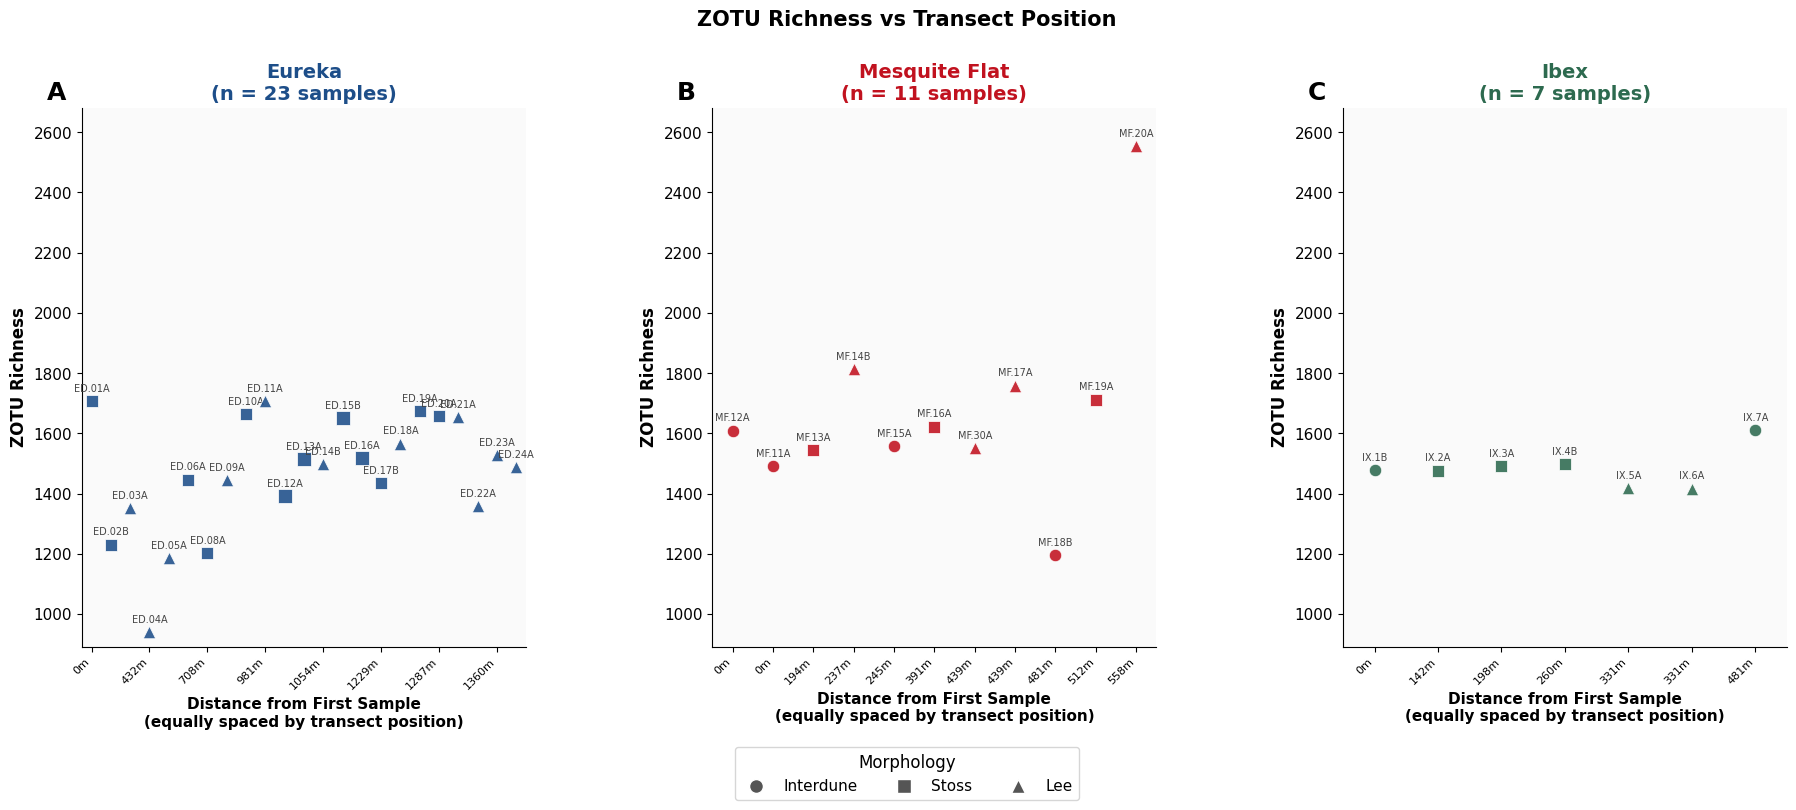

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# ============================
# LOAD COUNT TABLE
# ============================
path = "/content/zotutab_decontam_Final.csv"
raw  = pd.read_csv(path, header=None)

anatomy_row = raw.iloc[0]
header_row  = raw.iloc[1]

df = raw.iloc[2:].copy()
df.columns = header_row
df.reset_index(drop=True, inplace=True)

sample_cols = [c for c in df.columns[1:-7]
               if "Blank" not in str(c)]
df[sample_cols] = df[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)

zotu_rich = (df[sample_cols] > 0).astype(int).sum(axis=0)
print(f"ZOTU richness: {len(zotu_rich)} samples")

# ============================
# ANATOMY MAP
# ============================
anatomy_map = {}
col_list    = list(df.columns)
for s in sample_cols:
    try:
        col_idx        = col_list.index(s)
        anatomy_map[s] = str(anatomy_row.iloc[col_idx]).strip()
    except:
        anatomy_map[s] = "Interdune"

# ============================
# TRANSECT DEFINITIONS
# ============================
mesquite = [
    "MF.12A","MF.11A","MF.13A","MF.14B","MF.15A","MF.31B",
    "MF.16A","MF.30A","MF.17A","MF.18B","MF.19A","MF.20A"
]
eureka = [
    "ED.01A","ED.02B","ED.03A","ED.04A","ED.05A","ED.06A",
    "ED.08A","ED.09A","ED.10A","ED.11A","ED.12A","ED.13A",
    "ED.14B","ED.15B","ED.16A","ED.17B","ED.18A","ED.19A",
    "ED.20A","ED.21A","ED.22A","ED.23A","ED.24A"
]
ibex = [
    "IX.1B","IX.2A","IX.3A","IX.4B","IX.5A",
    "IX.6A","IX.7A"
]

transects = [
    ("Eureka",        eureka,   "#1d4e89"),
    ("Mesquite Flat", mesquite, "#c1121f"),
    ("Ibex",          ibex,     "#2d6a4f"),
]

MORPH_STYLE = {
    "Interdune":        ("o", 80),
    "Stoss":            ("s", 75),
    "Lee":              ("^", 80),
    "Stoss, Depth":     ("s", 75),
    "Stoss , Depth":    ("s", 75),
    "Interdune, Depth": ("o", 75),
    "Stoss, Star":      ("s", 110),
    "Stoss , Star":     ("s", 110),
    "Lee, Star":        ("^", 80),
    "Stoss, Crest":     ("s", 75),
}

# ============================
# COMPUTE DISTANCES
# ============================
def compute_distances(sample_list, coord_map, zotu_rich):
    valid = [s for s in sample_list
             if s in coord_map and s in zotu_rich.index]
    if len(valid) == 0:
        return [], [], []
    anchor_lat = coord_map[valid[0]]["Lat"]
    anchor_lon = coord_map[valid[0]]["Lon"]
    distances, richness, labels = [], [], []
    for s in valid:
        lat  = coord_map[s]["Lat"]
        lon  = coord_map[s]["Lon"]
        dist = haversine_m(anchor_lat, anchor_lon, lat, lon)
        distances.append(dist)
        richness.append(zotu_rich[s])
        labels.append(s)
    return distances, richness, labels

# ============================
# COLLECT DATA
# ============================
field_data = {}
for name, sample_list, color in transects:
    d, r, l = compute_distances(
        sample_list, coord_map, zotu_rich)
    field_data[name] = {
        "d": d, "r": r, "l": l, "color": color}

# shared y limits
all_rich = [v for fd in field_data.values()
            for v in fd["r"]]
y_min = min(all_rich) * 0.95
y_max = max(all_rich) * 1.05

# ============================
# FIGURE
# x axis = transect position index
# tick labels = actual distance in metres
# every sample gets equal horizontal space
# ============================
fig, axes = plt.subplots(
    1, 3, figsize=(22, 7),
    gridspec_kw={"wspace": 0.42})
fig.patch.set_facecolor("white")

panel_labels = "ABC"

for ax, (name, _, color), panel_lbl in zip(
        axes, transects, panel_labels):

    data      = field_data[name]
    distances = data["d"]
    richness  = data["r"]
    labels    = data["l"]

    if len(distances) == 0:
        ax.set_title(f"{name}\n(no data)", fontsize=14)
        continue

    n = len(distances)

    # x position = equal spacing 0,1,2,3...
    # gives every sample the same horizontal space
    x_positions = np.arange(n)

    # scatter
    for xi, r, s in zip(x_positions, richness, labels):
        anat   = anatomy_map.get(s, "Interdune")
        mk, sz = MORPH_STYLE.get(anat, ("o", 80))
        ax.scatter(xi, r, color=color,
                   marker=mk, s=sz,
                   edgecolors="white", linewidths=0.6,
                   alpha=0.88, zorder=3)
        ax.annotate(s, (xi, r),
                    textcoords="offset points",
                    xytext=(0, 7),
                    fontsize=7, ha="center",
                    color="#444444")

    # panel label
    ax.text(-0.08, 1.05, panel_lbl,
            transform=ax.transAxes,
            fontsize=18, fontweight="bold", va="top")

    ax.set_title(
        f"{name}\n(n = {n} samples)",
        fontsize=14, fontweight="bold", color=color)

    # ============================
    # X AXIS TICKS
    # show actual distance in metres
    # at every sample position
    # ============================
    # pick a subset of ticks if too many samples
    if n <= 12:
        tick_every = 1
    elif n <= 18:
        tick_every = 2
    else:
        tick_every = 3

    tick_pos    = x_positions[::tick_every]
    tick_labels = [f"{int(round(distances[i]))}m"
                   for i in range(n)][::tick_every]

    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels,
                       rotation=45, ha="right",
                       fontsize=8)
    ax.set_xlim(-0.5, n - 0.5)

    ax.set_xlabel("Distance from First Sample\n"
                  "(equally spaced by transect position)",
                  fontsize=11, fontweight="bold")
    ax.set_ylabel("ZOTU Richness", fontsize=12,
                  fontweight="bold")
    ax.set_ylim(y_min, y_max)
    ax.tick_params(axis="y", labelsize=11)
    ax.set_facecolor("#fafafa")
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

# ============================
# MORPHOLOGY LEGEND
# ============================
morph_handles = [
    mlines.Line2D([0],[0], marker="o", color="w",
                  markerfacecolor="#555555",
                  markeredgecolor="white",
                  markersize=10, label="Interdune"),
    mlines.Line2D([0],[0], marker="s", color="w",
                  markerfacecolor="#555555",
                  markeredgecolor="white",
                  markersize=10, label="Stoss"),
    mlines.Line2D([0],[0], marker="^", color="w",
                  markerfacecolor="#555555",
                  markeredgecolor="white",
                  markersize=10, label="Lee"),
]

fig.legend(
    handles=morph_handles,
    title="Morphology",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    fontsize=11, title_fontsize=12,
    frameon=True, edgecolor="#cccccc"
)

fig.suptitle(
    "ZOTU Richness vs Transect Position\n",
    fontsize=15, fontweight="bold", y=1.02)

plt.show()


In [6]:
# ============================
# PRINT MIN/MAX RICHNESS PER FIELD
# ============================
print("\n" + "="*70)
print("MIN / MAX ZOTU RICHNESS PER FIELD")
print("="*70)

for name, sample_list, color in transects:
    data = field_data[name]
    richness  = data["r"]
    labels    = data["l"]
    distances = data["d"]

    if len(richness) == 0:
        print(f"\n{name}: no data")
        continue

    min_idx = int(np.argmin(richness))
    max_idx = int(np.argmax(richness))
    n = len(richness)

    print(f"\n{name} (n = {n} samples):")
    print(f"  MIN richness: {richness[min_idx]}  "
          f"(sample: {labels[min_idx]}, distance: {distances[min_idx]:.0f} m)")
    print(f"  MAX richness: {richness[max_idx]}  "
          f"(sample: {labels[max_idx]}, distance: {distances[max_idx]:.0f} m)")
    print(f"  Range: {richness[min_idx]}-{richness[max_idx]} ZOTUs")
    print(f"  Is max at the most-downwind position (last in transect)? "
          f"{max_idx == n - 1}")

# ============================
# HIGHEST RICHNESS ACROSS ALL THREE FIELDS COMBINED
# ============================
print("\n" + "="*70)
print("HIGHEST RICHNESS ACROSS ALL THREE FIELDS COMBINED")
print("="*70)

all_samples = []
for name, sample_list, color in transects:
    data = field_data[name]
    for s, r in zip(data["l"], data["r"]):
        all_samples.append((name, s, r))

all_samples_sorted = sorted(all_samples, key=lambda x: -x[2])
print("\nTop 5 highest-richness samples across all fields:")
for field, sample, rich in all_samples_sorted[:5]:
    print(f"  {sample} ({field}): {rich} ZOTUs")


MIN / MAX ZOTU RICHNESS PER FIELD

Eureka (n = 23 samples):
  MIN richness: 939  (sample: ED.04A, distance: 432 m)
  MAX richness: 1707  (sample: ED.01A, distance: 0 m)
  Range: 939-1707 ZOTUs
  Is max at the most-downwind position (last in transect)? False

Mesquite Flat (n = 11 samples):
  MIN richness: 1196  (sample: MF.18B, distance: 481 m)
  MAX richness: 2554  (sample: MF.20A, distance: 558 m)
  Range: 1196-2554 ZOTUs
  Is max at the most-downwind position (last in transect)? True

Ibex (n = 7 samples):
  MIN richness: 1417  (sample: IX.6A, distance: 331 m)
  MAX richness: 1610  (sample: IX.7A, distance: 481 m)
  Range: 1417-1610 ZOTUs
  Is max at the most-downwind position (last in transect)? True

HIGHEST RICHNESS ACROSS ALL THREE FIELDS COMBINED

Top 5 highest-richness samples across all fields:
  MF.20A (Mesquite Flat): 2554 ZOTUs
  MF.14B (Mesquite Flat): 1813 ZOTUs
  MF.17A (Mesquite Flat): 1759 ZOTUs
  MF.19A (Mesquite Flat): 1712 ZOTUs
  ED.01A (Eureka): 1707 ZOTUs


OTU matrix: 52 samples x 6014 ZOTUs
PAIRWISE MANTEL — Bray-Curtis vs Geographic Distance
Spearman correlation, 999 permutations

Eureka (n=23 samples found)
  Mantel r=0.326  R²=0.106  p=0.0010  **

Mesquite Flat (n=11 samples found)
  Mantel r=0.237  R²=0.056  p=0.1060  ns

Ibex (n=7 samples found)
  Mantel r=0.604  R²=0.365  p=0.0430  *


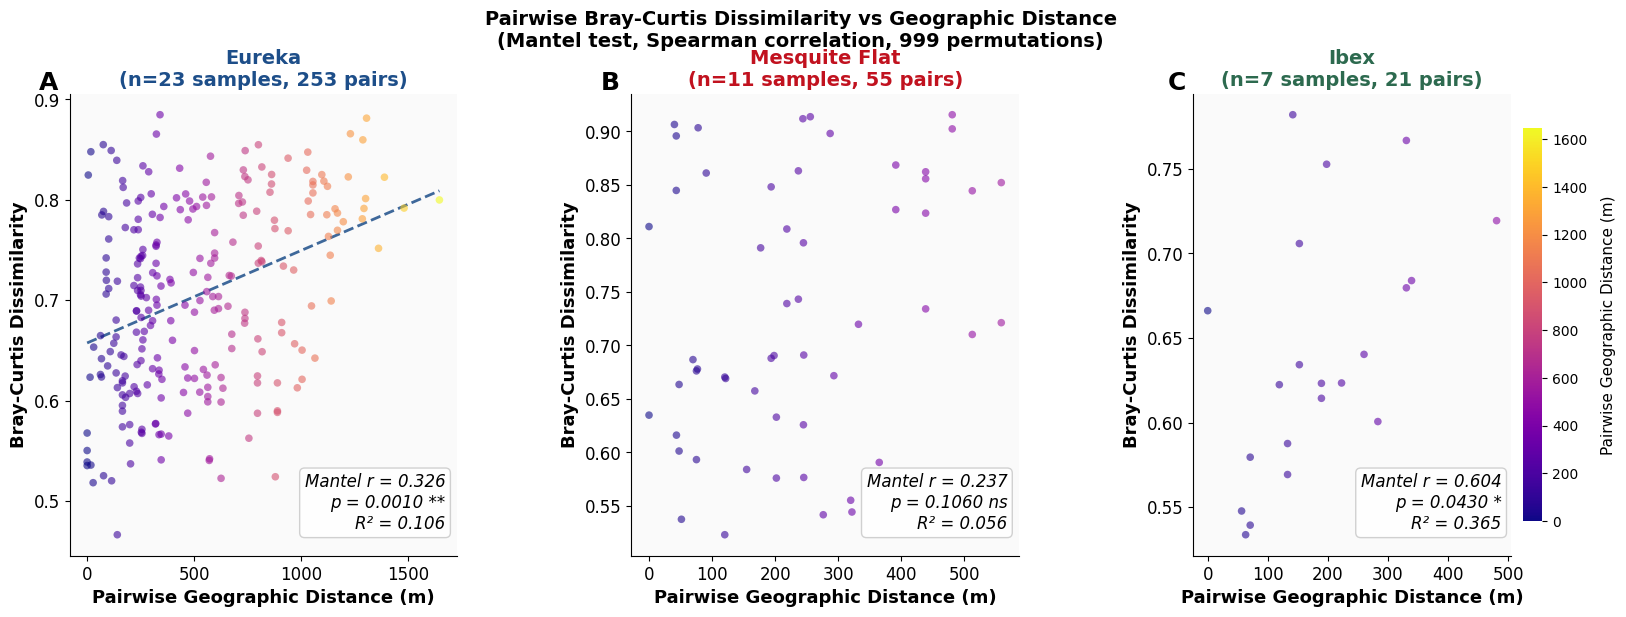

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import mantel, DistanceMatrix
from scipy.stats import linregress

# ============================
# LOAD RELATIVE ABUNDANCE FILE
# ============================
rel_path = "/content/zotutab_decontam_RelAbund_Final.csv"
raw      = pd.read_csv(rel_path, header=None)

header_row = raw.iloc[1]
df = raw.iloc[2:].copy()
df.columns = header_row
df.reset_index(drop=True, inplace=True)

tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]
zotu_col = df.columns[0]

sample_cols = [c for c in df.columns
               if c not in tax_cols
               and c != zotu_col
               and "Blank" not in str(c)]

df[sample_cols] = df[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df["Domain"] = df["Domain"].str.lower().str.strip()
df["Phylum"] = df["Phylum"].str.lower().str.strip()

micro = df[
    df["Domain"].isin(["bacteria", "archaea"]) &
    (df["Phylum"] != "bacteria") &
    df["Phylum"].notna()
].copy()

otu = (
    micro.set_index(zotu_col)[sample_cols]
    .T.fillna(0)
)
otu.index.name   = None
otu.columns.name = None

print(f"OTU matrix: {otu.shape[0]} samples x {otu.shape[1]} ZOTUs")

# ============================
# TRANSECT DEFINITIONS
# ============================
transects = {
    "Eureka": [
        "ED.01A","ED.02B","ED.03A","ED.04A","ED.05A","ED.06A",
        "ED.08A","ED.09A","ED.10A","ED.11A","ED.12A","ED.13A",
        "ED.14B","ED.15B","ED.16A","ED.17B","ED.18A","ED.19A",
        "ED.20A","ED.21A","ED.22A","ED.23A","ED.24A"
    ],
    "Mesquite Flat": [
        "MF.12A","MF.11A","MF.13A","MF.14B","MF.15A","MF.31B",
        "MF.16A","MF.30A","MF.17A","MF.18B","MF.19A","MF.20A"
    ],
    "Ibex": [
        "IX.1B","IX.2A","IX.3A","IX.4B","IX.5A",
        "IX.6A","IX.7A"
    ]
}

field_colors = {
    "Eureka":        "#1d4e89",
    "Mesquite Flat": "#c1121f",
    "Ibex":          "#2d6a4f"
}

# only show regression line where Mantel is significant
# Mesquite Flat is ns so no regression line
show_regression = {
    "Eureka":        True,
    "Mesquite Flat": False,
    "Ibex":          False,
}

# ============================
# MANTEL TEST FUNCTION
# ============================
def run_field_mantel(field, sample_list, otu_df,
                     coord_map, n_perm=999):

    samps = [s for s in sample_list
             if s in otu_df.index and s in coord_map]
    n     = len(samps)

    print(f"\n{field} (n={n} samples found)")

    if n < 4:
        print(f"  Insufficient samples — skipping")
        return None

    geo_mat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                lat1 = coord_map[samps[i]]["Lat"]
                lon1 = coord_map[samps[i]]["Lon"]
                lat2 = coord_map[samps[j]]["Lat"]
                lon2 = coord_map[samps[j]]["Lon"]
                geo_mat[i, j] = haversine_m(
                    lat1, lon1, lat2, lon2)

    sub    = otu_df.loc[samps].values.astype(float)
    bc_mat = squareform(pdist(sub, metric="braycurtis"))

    ids    = list(range(n))
    dm_geo = DistanceMatrix(geo_mat, ids=ids)
    dm_bc  = DistanceMatrix(bc_mat,  ids=ids)

    r, p, _ = mantel(dm_geo, dm_bc,
                     method="spearman",
                     permutations=n_perm)
    r2  = r ** 2
    sig = ("***" if p < 0.001 else
           "**"  if p < 0.01  else
           "*"   if p < 0.05  else "ns")

    print(f"  Mantel r={r:.3f}  R²={r2:.3f}  "
          f"p={p:.4f}  {sig}")

    idx   = np.triu_indices(n, k=1)
    x_geo = geo_mat[idx]
    y_bc  = bc_mat[idx]

    return {
        "r": r, "r2": r2, "p": p, "sig": sig,
        "samps": samps, "n": n,
        "x_geo": x_geo, "y_bc": y_bc,
    }

# ============================
# RUN FOR ALL THREE FIELDS
# ============================
print("=" * 55)
print("PAIRWISE MANTEL — Bray-Curtis vs Geographic Distance")
print("Spearman correlation, 999 permutations")
print("=" * 55)

results = {}
for field, slist in transects.items():
    results[field] = run_field_mantel(
        field, slist, otu, coord_map, n_perm=999)

## ============================
# FIGURE
# ============================
fields = [f for f in transects if results[f] is not None]

fig, axes = plt.subplots(
    1, len(fields),
    figsize=(6.5 * len(fields), 6),
    gridspec_kw={"wspace": 0.45})
fig.patch.set_facecolor("white")

if len(fields) == 1:
    axes = [axes]

panel_labels = "ABC"

# global distance range for consistent color scale
all_x_vals = np.concatenate([results[f]["x_geo"]
                              for f in fields])
vmin_global = all_x_vals.min()
vmax_global = all_x_vals.max()

for ax, field, panel_lbl in zip(axes, fields, panel_labels):
    res   = results[field]
    color = field_colors[field]

    x = res["x_geo"]
    y = res["y_bc"]

    # scatter — use global vmin/vmax for consistent color
    ax.scatter(x, y, c=x, cmap="plasma",
               alpha=0.6, s=30, linewidths=0,
               vmin=vmin_global, vmax=vmax_global,
               zorder=3)

    # regression line — only where significant
    if show_regression[field]:
        slope, intercept, _, _, _ = linregress(x, y)
        x_ln = np.linspace(x.min(), x.max(), 200)
        ax.plot(x_ln, slope * x_ln + intercept,
                color=color, linewidth=2,
                linestyle="--", alpha=0.85)

    # stats box
    ax.text(0.97, 0.05,
            f"Mantel r = {res['r']:.3f}\n"
            f"p = {res['p']:.4f} {res['sig']}\n"
            f"R² = {res['r2']:.3f}",
            transform=ax.transAxes,
            ha="right", va="bottom",
            fontsize=12, style="italic",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="white",
                      edgecolor="#cccccc",
                      alpha=0.9))

    ax.text(-0.08, 1.05, panel_lbl,
            transform=ax.transAxes,
            fontsize=18, fontweight="bold", va="top")

    ax.set_title(
        f"{field}\n(n={res['n']} samples, "
        f"{len(x)} pairs)",
        fontsize=14, fontweight="bold",
        color=color)
    ax.set_xlabel("Pairwise Geographic Distance (m)",
                  fontsize=13, fontweight="bold")
    ax.set_ylabel("Bray-Curtis Dissimilarity",
                  fontsize=13, fontweight="bold")
    ax.tick_params(labelsize=12)
    ax.set_facecolor("#fafafa")
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

# ============================
# SINGLE COLORBAR on Ibex panel
# added AFTER loop using fig.colorbar
# with explicit ax= to avoid duplicates
# ============================
sm = plt.cm.ScalarMappable(
         cmap="plasma",
         norm=plt.Normalize(vmin=vmin_global,
                            vmax=vmax_global))
sm.set_array([])

ibex_ax = axes[fields.index("Ibex")]
cb = fig.colorbar(sm, ax=ibex_ax,
                  location="right",
                  shrink=0.85,
                  pad=0.03,
                  aspect=20)
cb.set_label("Pairwise Geographic Distance (m)",
             fontsize=11, labelpad=10)
cb.ax.tick_params(labelsize=10)
cb.outline.set_visible(False)

fig.suptitle(
    "Pairwise Bray-Curtis Dissimilarity vs Geographic Distance\n"
    "(Mantel test, Spearman correlation, 999 permutations)",
    fontsize=14, fontweight="bold", y=1.02)


plt.show()


In [8]:
#GET TRANSECT DIFFERENCES FROM CSV
import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2

# ============================
# LOAD COORDINATE FILE
# ============================
coord_path = "/content/DEVA_Sample_Info.csv"
coords_raw = pd.read_csv(coord_path)

# clean sample names — convert dash to dot to match OTU table
def parse_sample_name(full_name):
    full_name = str(full_name).strip()
    parts     = full_name.split()
    code      = parts[-1]
    return code.replace("-", ".")

coords_raw["SampleID"] = coords_raw["Sample Name:"].apply(
    parse_sample_name)

# clean coordinates
coords_raw["Lat"] = pd.to_numeric(
    coords_raw["Latitude (°N)"],  errors="coerce")
coords_raw["Lon"] = pd.to_numeric(
    coords_raw["Longitude (°W)"], errors="coerce")

# longitude stored as positive W — make negative
coords_raw["Lon"] = coords_raw["Lon"].apply(
    lambda x: -abs(x) if pd.notna(x) else x)

# ============================
# CHECK FOR DUPLICATES
# ============================
print("All parsed sample IDs:")
print(coords_raw[["Sample Name:", "SampleID",
                   "Lat", "Lon"]].to_string())

dupes = coords_raw["SampleID"][
    coords_raw["SampleID"].duplicated()].tolist()
print(f"\nDuplicate SampleIDs: {dupes}")

# ============================
# KEEP FIRST OCCURRENCE
# drop duplicates before building map
# ============================
coords_clean = coords_raw.dropna(
    subset=["Lat", "Lon"]).drop_duplicates(
    subset="SampleID", keep="first")

coord_map = coords_clean.set_index("SampleID")[
    ["Lat", "Lon"]].to_dict(orient="index")

print(f"\nCoordinates loaded for {len(coord_map)} unique samples")

# spot check
print("\nSpot check:")
for s in ["MF.4B", "MF.12A", "ED.01A", "IX.1B"]:
    print(f"  {s}: {coord_map.get(s, 'MISSING')}")

# ============================
# HAVERSINE DISTANCE FUNCTION
# returns distance in metres
# ============================
def haversine_m(lat1, lon1, lat2, lon2):
    R    = 6371000
    phi1 = radians(lat1)
    phi2 = radians(lat2)
    dphi = radians(lat2 - lat1)
    dlam = radians(lon2 - lon1)
    a    = (sin(dphi/2)**2 +
            cos(phi1) * cos(phi2) * sin(dlam/2)**2)
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# ============================
# TEST DISTANCE CALCULATION
# ============================
print("\nDistance test — first to last Mesquite sample:")
mesquite = [
    "MF.12A","MF.11A","MF.13A","MF.14B","MF.15A","MF.31B",
    "MF.16A","MF.30A","MF.17A","MF.18B","MF.19A","MF.20A"
]

anchor = coord_map.get("MF.12A")
if anchor:
    for s in mesquite:
        c = coord_map.get(s)
        if c:
            d = haversine_m(anchor["Lat"], anchor["Lon"],
                            c["Lat"], c["Lon"])
            print(f"  {s}: {d:.1f} m")
        else:
            print(f"  {s}: MISSING coords")

All parsed sample IDs:
                  Sample Name: SampleID        Lat        Lon
0    MESQUITE FLATS SAND MF-4B    MF.4B  36.616170 -117.11751
1    MESQUITE FLATS SAND MF-5B    MF.5B  36.614740 -117.11369
2    MESQUITE FLATS SAND MF-6B    MF.6B  36.614722 -117.11330
3    MESQUITE FLATS SAND MF-7B    MF.7B  36.613910 -117.11299
4    MESQUITE FLATS SAND MF-8B    MF.8B  36.613910 -117.11299
5   MESQUITE FLATS SAND MF-11A   MF.11A  36.615590 -117.12206
6   MESQUITE FLATS SAND MF-12A   MF.12A  36.615590 -117.12206
7   MESQUITE FLATS SAND MF-13A   MF.13A  36.614190 -117.12077
8   MESQUITE FLATS SAND MF-14B   MF.14B  36.613910 -117.12043
9   MESQUITE FLATS SAND MF-15A   MF.15A  36.613540 -117.12106
10  MESQUITE FLATS SAND MF-16A   MF.16A  36.612890 -117.11925
11  MESQUITE FLATS SAND MF-17A   MF.17A  36.612530 -117.11896
12  MESQUITE FLATS SAND MF-18B   MF.18B  36.612180 -117.11875
13  MESQUITE FLATS SAND MF-19A   MF.19A  36.612100 -117.11831
14  MESQUITE FLATS SAND MF-20A   MF.20A  36.611

ZOTU richness: 52 samples
OTU matrix: 52 samples x 6014 ZOTUs
PAIRWISE MANTEL — Bray-Curtis vs Geographic Distance

Eureka (n=23 samples found)
  Mantel r=0.326  R²=0.106  p=0.0020  **

Mesquite Flat (n=11 samples found)
  Mantel r=0.237  R²=0.056  p=0.1050  ns

Ibex (n=7 samples found)
  Mantel r=0.604  R²=0.365  p=0.0280  *


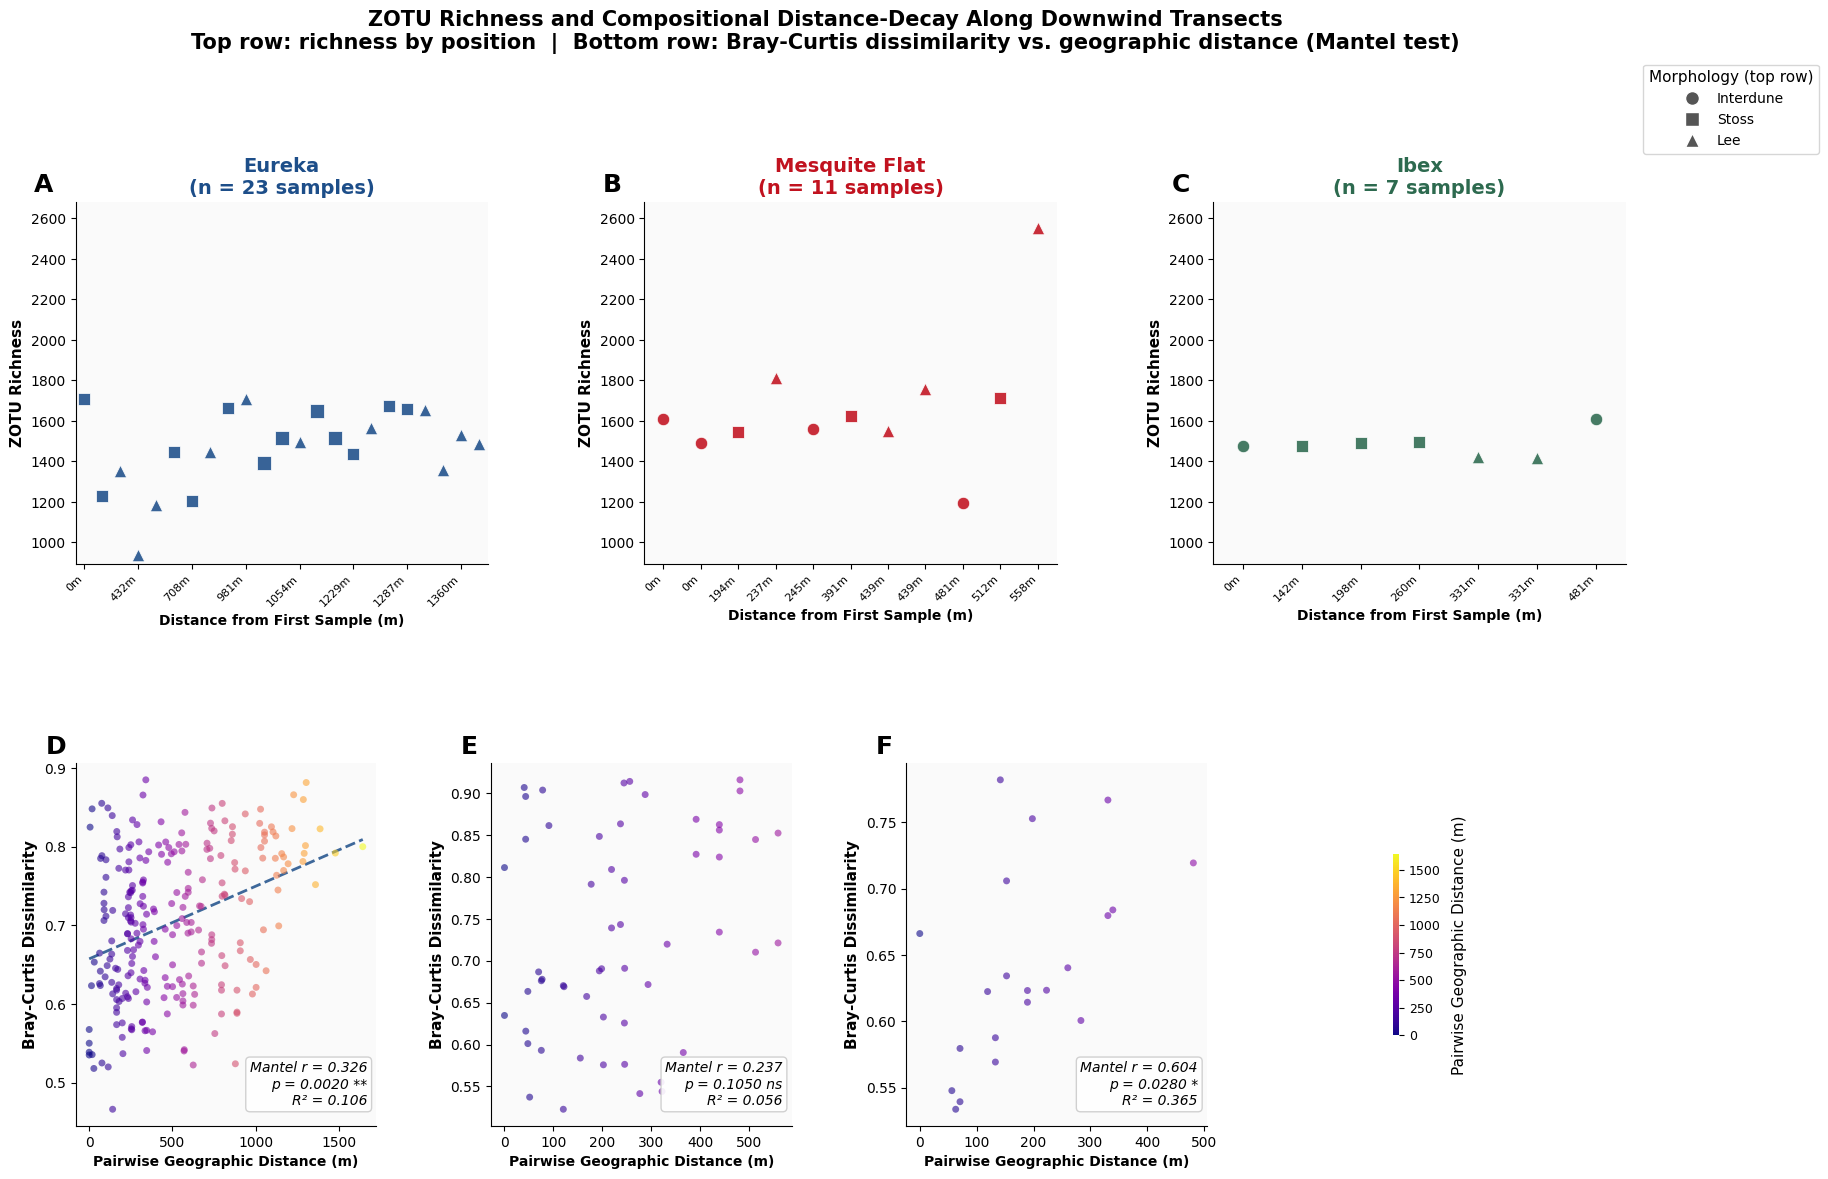

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import mantel, DistanceMatrix
from scipy.stats import linregress

# ============================
# TRANSECT DEFINITIONS (shared by both rows)
# ============================
transects_order = ["Eureka", "Mesquite Flat", "Ibex"]

transect_samples = {
    "Eureka": [
        "ED.01A","ED.02B","ED.03A","ED.04A","ED.05A","ED.06A",
        "ED.08A","ED.09A","ED.10A","ED.11A","ED.12A","ED.13A",
        "ED.14B","ED.15B","ED.16A","ED.17B","ED.18A","ED.19A",
        "ED.20A","ED.21A","ED.22A","ED.23A","ED.24A"
    ],
    "Mesquite Flat": [
        "MF.12A","MF.11A","MF.13A","MF.14B","MF.15A","MF.31B",
        "MF.16A","MF.30A","MF.17A","MF.18B","MF.19A","MF.20A"
    ],
    "Ibex": [
        "IX.1B","IX.2A","IX.3A","IX.4B","IX.5A",
        "IX.6A","IX.7A"
    ]
}

field_colors = {
    "Eureka":        "#1d4e89",
    "Mesquite Flat": "#c1121f",
    "Ibex":          "#2d6a4f"
}

# only draw regression line where Mantel is significant
show_regression = {
    "Eureka":        True,
    "Mesquite Flat": False,
    "Ibex":          False,
}

MORPH_STYLE = {
    "Interdune":        ("o", 80),
    "Stoss":            ("s", 75),
    "Lee":              ("^", 80),
    "Stoss, Depth":     ("s", 75),
    "Stoss , Depth":    ("s", 75),
    "Interdune, Depth": ("o", 75),
    "Stoss, Star":      ("s", 110),
    "Stoss , Star":     ("s", 110),
    "Lee, Star":        ("^", 80),
    "Stoss, Crest":     ("s", 75),
}

# ============================
# ROW 1 DATA: ZOTU RICHNESS (count table)
# ============================
count_path = "/content/zotutab_decontam_Final.csv"
raw_counts = pd.read_csv(count_path, header=None)

anatomy_row = raw_counts.iloc[0]
header_row_counts = raw_counts.iloc[1]

df_counts = raw_counts.iloc[2:].copy()
df_counts.columns = header_row_counts
df_counts.reset_index(drop=True, inplace=True)

sample_cols_counts = [c for c in df_counts.columns[1:-7]
                       if "Blank" not in str(c)]
df_counts[sample_cols_counts] = df_counts[sample_cols_counts].apply(
    pd.to_numeric, errors="coerce").fillna(0)

zotu_rich = (df_counts[sample_cols_counts] > 0).astype(int).sum(axis=0)
print(f"ZOTU richness: {len(zotu_rich)} samples")

anatomy_map = {}
col_list = list(df_counts.columns)
for s in sample_cols_counts:
    try:
        col_idx = col_list.index(s)
        anatomy_map[s] = str(anatomy_row.iloc[col_idx]).strip()
    except:
        anatomy_map[s] = "Interdune"

def compute_distances(sample_list, coord_map, zotu_rich):
    valid = [s for s in sample_list
             if s in coord_map and s in zotu_rich.index]
    if len(valid) == 0:
        return [], [], []
    anchor_lat = coord_map[valid[0]]["Lat"]
    anchor_lon = coord_map[valid[0]]["Lon"]
    distances, richness, labels = [], [], []
    for s in valid:
        lat, lon = coord_map[s]["Lat"], coord_map[s]["Lon"]
        dist = haversine_m(anchor_lat, anchor_lon, lat, lon)
        distances.append(dist)
        richness.append(zotu_rich[s])
        labels.append(s)
    return distances, richness, labels

richness_data = {}
for field in transects_order:
    d, r, l = compute_distances(
        transect_samples[field], coord_map, zotu_rich)
    richness_data[field] = {"d": d, "r": r, "l": l}

all_rich = [v for fd in richness_data.values() for v in fd["r"]]
y_min_rich = min(all_rich) * 0.95
y_max_rich = max(all_rich) * 1.05

# ============================
# ROW 2 DATA: MANTEL (relative abundance table)
# ============================
rel_path = "/content/zotutab_decontam_RelAbund_Final.csv"
raw_rel  = pd.read_csv(rel_path, header=None)

header_row_rel = raw_rel.iloc[1]
df_rel = raw_rel.iloc[2:].copy()
df_rel.columns = header_row_rel
df_rel.reset_index(drop=True, inplace=True)

tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]
zotu_col = df_rel.columns[0]

sample_cols_rel = [c for c in df_rel.columns
                    if c not in tax_cols
                    and c != zotu_col
                    and "Blank" not in str(c)]

df_rel[sample_cols_rel] = df_rel[sample_cols_rel].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df_rel["Domain"] = df_rel["Domain"].str.lower().str.strip()
df_rel["Phylum"] = df_rel["Phylum"].str.lower().str.strip()

micro = df_rel[
    df_rel["Domain"].isin(["bacteria", "archaea"]) &
    (df_rel["Phylum"] != "bacteria") &
    df_rel["Phylum"].notna()
].copy()

otu = (
    micro.set_index(zotu_col)[sample_cols_rel]
    .T.fillna(0)
)
otu.index.name = None
otu.columns.name = None

print(f"OTU matrix: {otu.shape[0]} samples x {otu.shape[1]} ZOTUs")

def run_field_mantel(field, sample_list, otu_df, coord_map, n_perm=999):
    samps = [s for s in sample_list
             if s in otu_df.index and s in coord_map]
    n = len(samps)
    print(f"\n{field} (n={n} samples found)")
    if n < 4:
        print(f"  Insufficient samples — skipping")
        return None

    geo_mat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                lat1, lon1 = coord_map[samps[i]]["Lat"], coord_map[samps[i]]["Lon"]
                lat2, lon2 = coord_map[samps[j]]["Lat"], coord_map[samps[j]]["Lon"]
                geo_mat[i, j] = haversine_m(lat1, lon1, lat2, lon2)

    sub = otu_df.loc[samps].values.astype(float)
    bc_mat = squareform(pdist(sub, metric="braycurtis"))

    ids = list(range(n))
    dm_geo = DistanceMatrix(geo_mat, ids=ids)
    dm_bc  = DistanceMatrix(bc_mat, ids=ids)

    r, p, _ = mantel(dm_geo, dm_bc, method="spearman", permutations=n_perm)
    r2 = r ** 2
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"  Mantel r={r:.3f}  R²={r2:.3f}  p={p:.4f}  {sig}")

    idx = np.triu_indices(n, k=1)
    return {
        "r": r, "r2": r2, "p": p, "sig": sig,
        "samps": samps, "n": n,
        "x_geo": geo_mat[idx], "y_bc": bc_mat[idx],
    }

print("=" * 55)
print("PAIRWISE MANTEL — Bray-Curtis vs Geographic Distance")
print("=" * 55)

mantel_results = {}
for field in transects_order:
    mantel_results[field] = run_field_mantel(
        field, transect_samples[field], otu, coord_map, n_perm=999)

all_x_vals = np.concatenate([mantel_results[f]["x_geo"] for f in transects_order])
vmin_global, vmax_global = all_x_vals.min(), all_x_vals.max()

# ============================
# COMBINED FIGURE — 2 rows x 3 cols
# Row 1 (A,B,C): ZOTU richness along transect
# Row 2 (D,E,F): Mantel distance-decay, same field per column
# ============================
fig, axes = plt.subplots(
    2, 3, figsize=(20, 12),
    gridspec_kw={"wspace": 0.38, "hspace": 0.55})
fig.patch.set_facecolor("white")

panel_labels = ["A", "B", "C", "D", "E", "F"]

for col, field in enumerate(transects_order):
    color = field_colors[field]

    # ---------- ROW 1: RICHNESS ----------
    ax_top = axes[0, col]
    rd = richness_data[field]
    distances, richness, labels = rd["d"], rd["r"], rd["l"]
    n = len(distances)

    if n == 0:
        ax_top.set_title(f"{field}\n(no data)", fontsize=13)
    else:
        x_positions = np.arange(n)
        for xi, r_val, s in zip(x_positions, richness, labels):
            anat = anatomy_map.get(s, "Interdune")
            mk, sz = MORPH_STYLE.get(anat, ("o", 80))
            ax_top.scatter(xi, r_val, color=color, marker=mk, s=sz,
                           edgecolors="white", linewidths=0.6,
                           alpha=0.88, zorder=3)

        if n <= 12:
            tick_every = 1
        elif n <= 18:
            tick_every = 2
        else:
            tick_every = 3
        tick_pos = x_positions[::tick_every]
        tick_labels = [f"{int(round(distances[i]))}m"
                       for i in range(n)][::tick_every]
        ax_top.set_xticks(tick_pos)
        ax_top.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)
        ax_top.set_xlim(-0.5, n - 0.5)
        ax_top.set_ylim(y_min_rich, y_max_rich)

    ax_top.text(-0.10, 1.08, panel_labels[col], transform=ax_top.transAxes,
                fontsize=18, fontweight="bold", va="top")
    ax_top.set_title(f"{field}\n(n = {n} samples)",
                      fontsize=14, fontweight="bold", color=color)
    ax_top.set_xlabel("Distance from First Sample (m)", fontsize=10, fontweight="bold")
    ax_top.set_ylabel("ZOTU Richness", fontsize=11, fontweight="bold")
    ax_top.tick_params(axis="y", labelsize=10)
    ax_top.set_facecolor("#fafafa")
    for sp in ["top", "right"]:
        ax_top.spines[sp].set_visible(False)

    # ---------- ROW 2: MANTEL ----------
    ax_bot = axes[1, col]
    res = mantel_results[field]

    if res is None:
        ax_bot.set_title(f"{field}\n(insufficient data)", fontsize=13)
    else:
        x, y = res["x_geo"], res["y_bc"]
        ax_bot.scatter(x, y, c=x, cmap="plasma", alpha=0.6, s=25,
                       linewidths=0, vmin=vmin_global, vmax=vmax_global, zorder=3)

        if show_regression[field]:
            slope, intercept, _, _, _ = linregress(x, y)
            x_ln = np.linspace(x.min(), x.max(), 200)
            ax_bot.plot(x_ln, slope * x_ln + intercept,
                       color=color, linewidth=2, linestyle="--", alpha=0.85)

        ax_bot.text(0.97, 0.05,
                    f"Mantel r = {res['r']:.3f}\n"
                    f"p = {res['p']:.4f} {res['sig']}\n"
                    f"R² = {res['r2']:.3f}",
                    transform=ax_bot.transAxes,
                    ha="right", va="bottom", fontsize=10, style="italic",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                              edgecolor="#cccccc", alpha=0.9))

    ax_bot.text(-0.10, 1.08, panel_labels[col + 3], transform=ax_bot.transAxes,
                fontsize=18, fontweight="bold", va="top")
    ax_bot.set_xlabel("Pairwise Geographic Distance (m)", fontsize=10, fontweight="bold")
    ax_bot.set_ylabel("Bray-Curtis Dissimilarity", fontsize=11, fontweight="bold")
    ax_bot.tick_params(labelsize=10)
    ax_bot.set_facecolor("#fafafa")
    for sp in ["top", "right"]:
        ax_bot.spines[sp].set_visible(False)

# ============================
# SHARED COLORBAR — spans bottom row, encodes pairwise distance
# ============================
sm = plt.cm.ScalarMappable(cmap="plasma",
                            norm=plt.Normalize(vmin=vmin_global, vmax=vmax_global))
sm.set_array([])
cb = fig.colorbar(sm, ax=axes[1, :], location="right",
                   shrink=0.5, pad=0.12, aspect=30)
cb.set_label("Pairwise Geographic Distance (m)", fontsize=11, labelpad=8)
cb.ax.tick_params(labelsize=9)
cb.outline.set_visible(False)

# ============================
# MORPHOLOGY LEGEND (applies to top row only)
# ============================
morph_handles = [
    mlines.Line2D([0],[0], marker="o", color="w", markerfacecolor="#555555",
                  markeredgecolor="white", markersize=10, label="Interdune"),
    mlines.Line2D([0],[0], marker="s", color="w", markerfacecolor="#555555",
                  markeredgecolor="white", markersize=10, label="Stoss"),
    mlines.Line2D([0],[0], marker="^", color="w", markerfacecolor="#555555",
                  markeredgecolor="white", markersize=10, label="Lee"),
]
fig.legend(handles=morph_handles, title="Morphology (top row)",
           loc="upper right", bbox_to_anchor=(1.0, 1.0),
           ncol=1, fontsize=10, title_fontsize=11,
           frameon=True, edgecolor="#cccccc")

fig.suptitle(
    "ZOTU Richness and Compositional Distance-Decay Along Downwind Transects\n"
    "Top row: richness by position  |  Bottom row: Bray-Curtis dissimilarity vs. geographic distance (Mantel test)",
    fontsize=15, fontweight="bold", y=1.04)

plt.show()

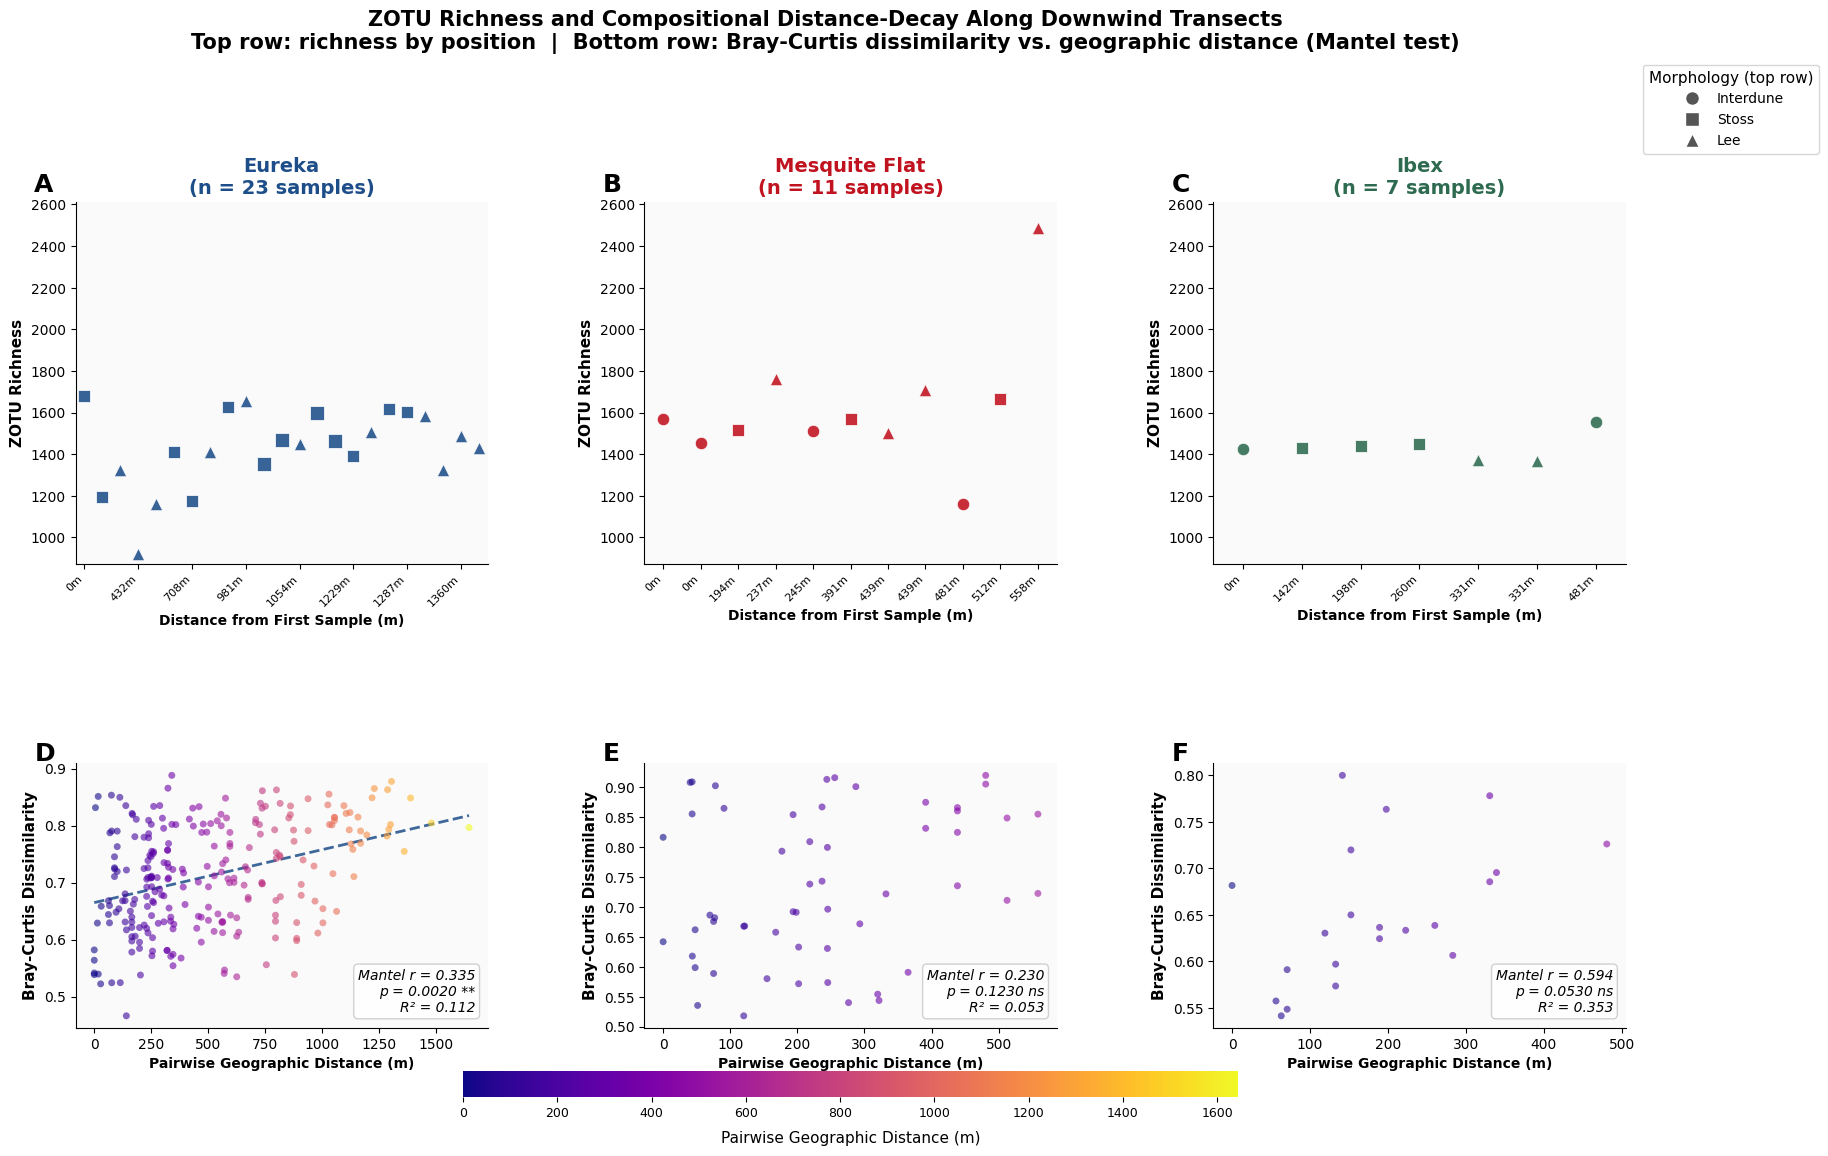

In [ ]:
# ============================
# COMBINED FIGURE — 2 rows x 3 cols
# Row 1 (A,B,C): ZOTU richness along transect
# Row 2 (D,E,F): Mantel distance-decay, same field per column
# ============================
fig, axes = plt.subplots(
    2, 3, figsize=(20, 12),
    gridspec_kw={"wspace": 0.38, "hspace": 0.55})
fig.patch.set_facecolor("white")

panel_labels = ["A", "B", "C", "D", "E", "F"]

for col, field in enumerate(transects_order):
    color = field_colors[field]

    # ---------- ROW 1: RICHNESS ----------
    ax_top = axes[0, col]
    rd = richness_data[field]
    distances, richness, labels = rd["d"], rd["r"], rd["l"]
    n = len(distances)

    if n == 0:
        ax_top.set_title(f"{field}\n(no data)", fontsize=13)
    else:
        x_positions = np.arange(n)
        for xi, r_val, s in zip(x_positions, richness, labels):
            anat = anatomy_map.get(s, "Interdune")
            mk, sz = MORPH_STYLE.get(anat, ("o", 80))
            ax_top.scatter(xi, r_val, color=color, marker=mk, s=sz,
                           edgecolors="white", linewidths=0.6,
                           alpha=0.88, zorder=3)

        if n <= 12:
            tick_every = 1
        elif n <= 18:
            tick_every = 2
        else:
            tick_every = 3
        tick_pos = x_positions[::tick_every]
        tick_labels = [f"{int(round(distances[i]))}m"
                       for i in range(n)][::tick_every]
        ax_top.set_xticks(tick_pos)
        ax_top.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)
        ax_top.set_xlim(-0.5, n - 0.5)
        ax_top.set_ylim(y_min_rich, y_max_rich)

    ax_top.text(-0.10, 1.08, panel_labels[col], transform=ax_top.transAxes,
                fontsize=18, fontweight="bold", va="top")
    ax_top.set_title(f"{field}\n(n = {n} samples)",
                      fontsize=14, fontweight="bold", color=color)
    ax_top.set_xlabel("Distance from First Sample (m)", fontsize=10, fontweight="bold")
    ax_top.set_ylabel("ZOTU Richness", fontsize=11, fontweight="bold")
    ax_top.tick_params(axis="y", labelsize=10)
    ax_top.set_facecolor("#fafafa")
    for sp in ["top", "right"]:
        ax_top.spines[sp].set_visible(False)

    # ---------- ROW 2: MANTEL ----------
    ax_bot = axes[1, col]
    res = mantel_results[field]

    if res is None:
        ax_bot.set_title(f"{field}\n(insufficient data)", fontsize=13)
    else:
        x, y = res["x_geo"], res["y_bc"]
        ax_bot.scatter(x, y, c=x, cmap="plasma", alpha=0.6, s=25,
                       linewidths=0, vmin=vmin_global, vmax=vmax_global, zorder=3)

        if show_regression[field]:
            slope, intercept, _, _, _ = linregress(x, y)
            x_ln = np.linspace(x.min(), x.max(), 200)
            ax_bot.plot(x_ln, slope * x_ln + intercept,
                       color=color, linewidth=2, linestyle="--", alpha=0.85)

        ax_bot.text(0.97, 0.05,
                    f"Mantel r = {res['r']:.3f}\n"
                    f"p = {res['p']:.4f} {res['sig']}\n"
                    f"R² = {res['r2']:.3f}",
                    transform=ax_bot.transAxes,
                    ha="right", va="bottom", fontsize=10, style="italic",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                              edgecolor="#cccccc", alpha=0.9))

    ax_bot.text(-0.10, 1.08, panel_labels[col + 3], transform=ax_bot.transAxes,
                fontsize=18, fontweight="bold", va="top")
    ax_bot.set_xlabel("Pairwise Geographic Distance (m)", fontsize=10, fontweight="bold")
    ax_bot.set_ylabel("Bray-Curtis Dissimilarity", fontsize=11, fontweight="bold")
    ax_bot.tick_params(labelsize=10)
    ax_bot.set_facecolor("#fafafa")
    for sp in ["top", "right"]:
        ax_bot.spines[sp].set_visible(False)

# ============================
# SHARED COLORBAR — spans bottom row, encodes pairwise distance
# ============================

sm = plt.cm.ScalarMappable(cmap="plasma",
                            norm=plt.Normalize(vmin=vmin_global, vmax=vmax_global))
sm.set_array([])
cb = fig.colorbar(sm, ax=axes[1, :], location="bottom",
                   shrink=0.5, pad=0.12, aspect=30)
cb.set_label("Pairwise Geographic Distance (m)", fontsize=11, labelpad=8)
cb.ax.tick_params(labelsize=9)
cb.outline.set_visible(False)

# ============================
# MORPHOLOGY LEGEND (applies to top row only)
# ============================
morph_handles = [
    mlines.Line2D([0],[0], marker="o", color="w", markerfacecolor="#555555",
                  markeredgecolor="white", markersize=10, label="Interdune"),
    mlines.Line2D([0],[0], marker="s", color="w", markerfacecolor="#555555",
                  markeredgecolor="white", markersize=10, label="Stoss"),
    mlines.Line2D([0],[0], marker="^", color="w", markerfacecolor="#555555",
                  markeredgecolor="white", markersize=10, label="Lee"),
]
fig.legend(handles=morph_handles, title="Morphology (top row)",
           loc="upper right", bbox_to_anchor=(1.0, 1.0),
           ncol=1, fontsize=10, title_fontsize=11,
           frameon=True, edgecolor="#cccccc")

fig.suptitle(
    "ZOTU Richness and Compositional Distance-Decay Along Downwind Transects\n"
    "Top row: richness by position  |  Bottom row: Bray-Curtis dissimilarity vs. geographic distance (Mantel test)",
    fontsize=15, fontweight="bold", y=1.04)

plt.show()

Eureka: Mantel r=0.326  R²=0.106  p=0.0010  **
Mesquite Flat: Mantel r=0.237  R²=0.056  p=0.1170  ns
Ibex: Mantel r=0.604  R²=0.365  p=0.0430  *


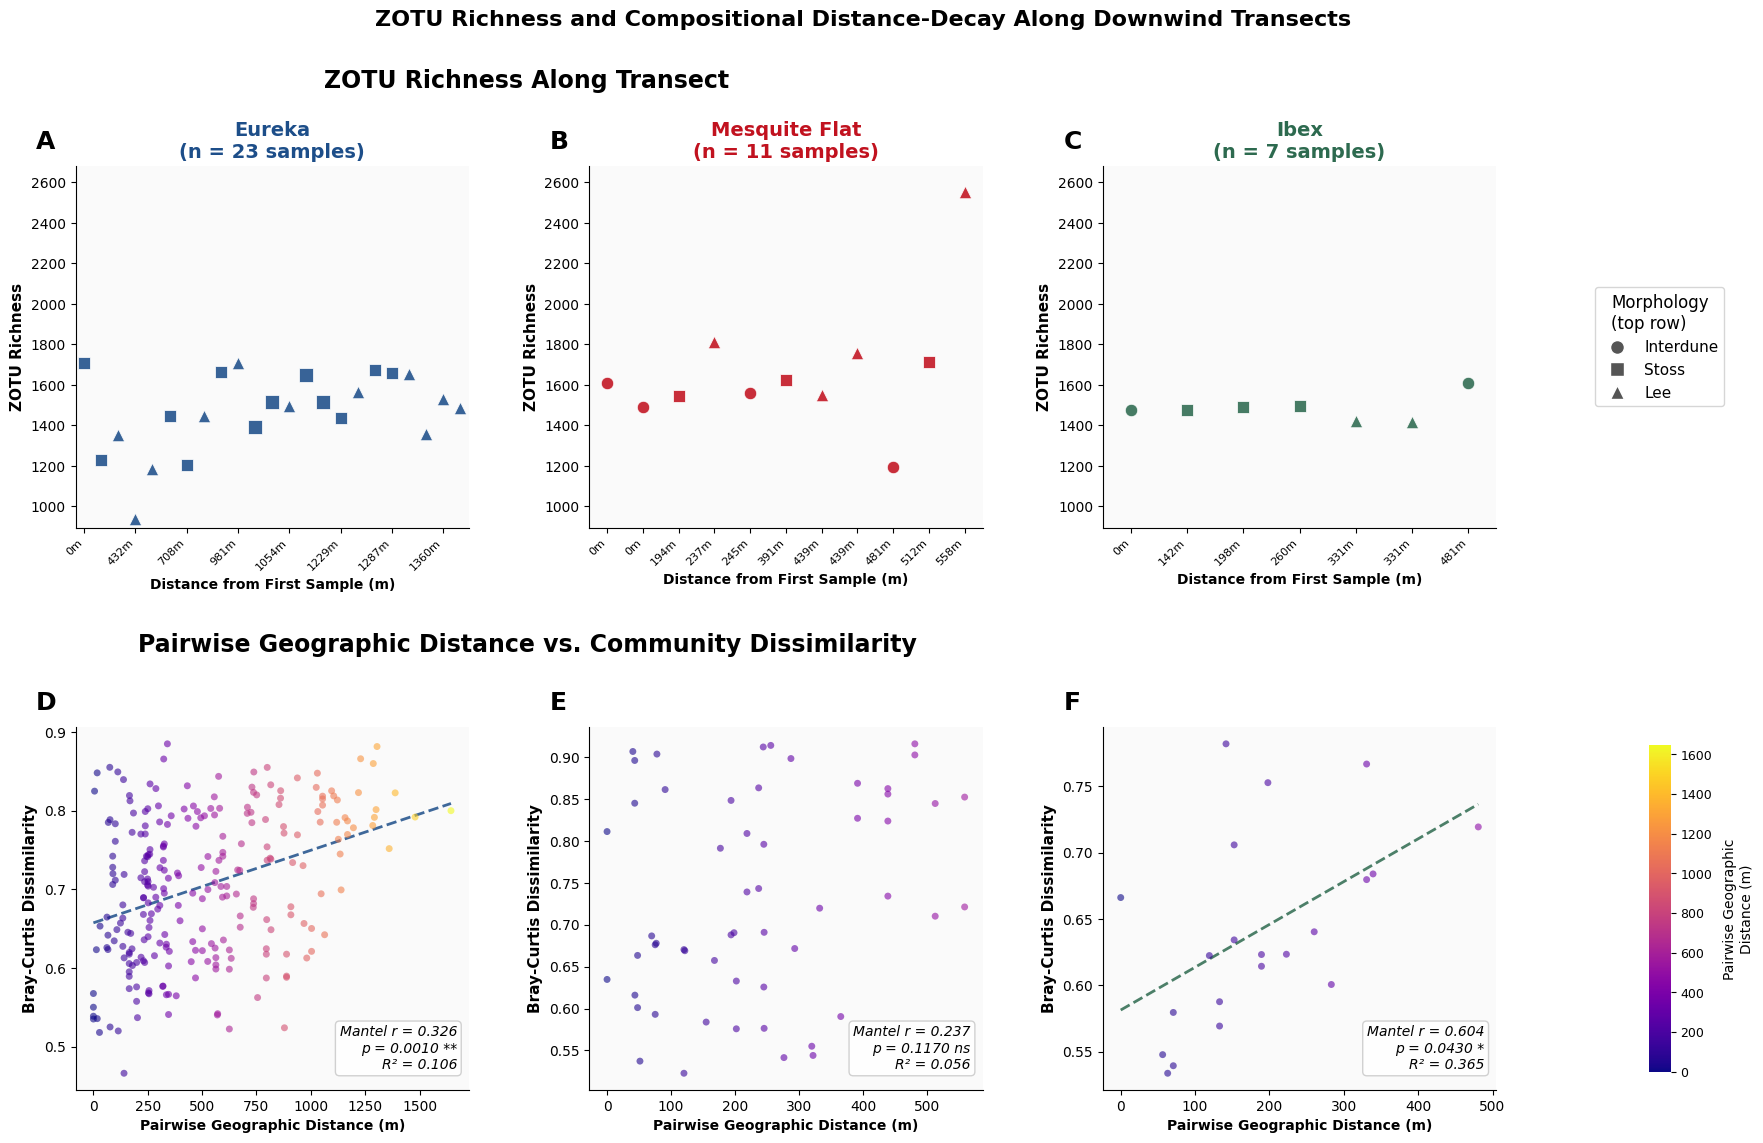

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.gridspec import GridSpec
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import mantel, DistanceMatrix
from scipy.stats import linregress

# ============================
# TRANSECT DEFINITIONS (shared by both rows)
# ============================
transects_order = ["Eureka", "Mesquite Flat", "Ibex"]

transect_samples = {
    "Eureka": [
        "ED.01A","ED.02B","ED.03A","ED.04A","ED.05A","ED.06A",
        "ED.08A","ED.09A","ED.10A","ED.11A","ED.12A","ED.13A",
        "ED.14B","ED.15B","ED.16A","ED.17B","ED.18A","ED.19A",
        "ED.20A","ED.21A","ED.22A","ED.23A","ED.24A"
    ],
    "Mesquite Flat": [
        "MF.12A","MF.11A","MF.13A","MF.14B","MF.15A","MF.31B",
        "MF.16A","MF.30A","MF.17A","MF.18B","MF.19A","MF.20A"
    ],
    "Ibex": [
        "IX.1B","IX.2A","IX.3A","IX.4B","IX.5A",
        "IX.6A","IX.7A"
    ]
}

field_colors = {
    "Eureka":        "#1d4e89",
    "Mesquite Flat": "#c1121f",
    "Ibex":          "#2d6a4f"
}

show_regression = {
    "Eureka":        True,
    "Mesquite Flat": False,
    "Ibex":          True,
}

MORPH_STYLE = {
    "Interdune":        ("o", 80),
    "Stoss":            ("s", 75),
    "Lee":              ("^", 80),
    "Stoss, Depth":     ("s", 75),
    "Stoss , Depth":    ("s", 75),
    "Interdune, Depth": ("o", 75),
    "Stoss, Star":      ("s", 110),
    "Stoss , Star":     ("s", 110),
    "Lee, Star":        ("^", 80),
    "Stoss, Crest":     ("s", 75),
}

# ============================
# ROW 1 DATA: ZOTU RICHNESS (count table)
# ============================
count_path = "/content/zotutab_decontam_Final.csv"
raw_counts = pd.read_csv(count_path, header=None)

anatomy_row = raw_counts.iloc[0]
header_row_counts = raw_counts.iloc[1]

df_counts = raw_counts.iloc[2:].copy()
df_counts.columns = header_row_counts
df_counts.reset_index(drop=True, inplace=True)

sample_cols_counts = [c for c in df_counts.columns[1:-7]
                       if "Blank" not in str(c)]
df_counts[sample_cols_counts] = df_counts[sample_cols_counts].apply(
    pd.to_numeric, errors="coerce").fillna(0)

zotu_rich = (df_counts[sample_cols_counts] > 0).astype(int).sum(axis=0)

anatomy_map = {}
col_list = list(df_counts.columns)
for s in sample_cols_counts:
    try:
        col_idx = col_list.index(s)
        anatomy_map[s] = str(anatomy_row.iloc[col_idx]).strip()
    except:
        anatomy_map[s] = "Interdune"

def compute_distances(sample_list, coord_map, zotu_rich):
    valid = [s for s in sample_list
             if s in coord_map and s in zotu_rich.index]
    if len(valid) == 0:
        return [], [], []
    anchor_lat = coord_map[valid[0]]["Lat"]
    anchor_lon = coord_map[valid[0]]["Lon"]
    distances, richness, labels = [], [], []
    for s in valid:
        lat, lon = coord_map[s]["Lat"], coord_map[s]["Lon"]
        dist = haversine_m(anchor_lat, anchor_lon, lat, lon)
        distances.append(dist)
        richness.append(zotu_rich[s])
        labels.append(s)
    return distances, richness, labels

richness_data = {}
for field in transects_order:
    d, r, l = compute_distances(
        transect_samples[field], coord_map, zotu_rich)
    richness_data[field] = {"d": d, "r": r, "l": l}

all_rich = [v for fd in richness_data.values() for v in fd["r"]]
y_min_rich = min(all_rich) * 0.95
y_max_rich = max(all_rich) * 1.05

# ============================
# ROW 2 DATA: MANTEL (relative abundance table)
# ============================
rel_path = "/content/zotutab_decontam_RelAbund_Final.csv"
raw_rel  = pd.read_csv(rel_path, header=None)

header_row_rel = raw_rel.iloc[1]
df_rel = raw_rel.iloc[2:].copy()
df_rel.columns = header_row_rel
df_rel.reset_index(drop=True, inplace=True)

tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]
zotu_col = df_rel.columns[0]

sample_cols_rel = [c for c in df_rel.columns
                    if c not in tax_cols
                    and c != zotu_col
                    and "Blank" not in str(c)]

df_rel[sample_cols_rel] = df_rel[sample_cols_rel].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df_rel["Domain"] = df_rel["Domain"].str.lower().str.strip()
df_rel["Phylum"] = df_rel["Phylum"].str.lower().str.strip()

micro = df_rel[
    df_rel["Domain"].isin(["bacteria", "archaea"]) &
    (df_rel["Phylum"] != "bacteria") &
    df_rel["Phylum"].notna()
].copy()

otu = (
    micro.set_index(zotu_col)[sample_cols_rel]
    .T.fillna(0)
)
otu.index.name = None
otu.columns.name = None

def run_field_mantel(field, sample_list, otu_df, coord_map, n_perm=999):
    samps = [s for s in sample_list
             if s in otu_df.index and s in coord_map]
    n = len(samps)
    if n < 4:
        print(f"{field}: insufficient samples — skipping")
        return None

    geo_mat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                lat1, lon1 = coord_map[samps[i]]["Lat"], coord_map[samps[i]]["Lon"]
                lat2, lon2 = coord_map[samps[j]]["Lat"], coord_map[samps[j]]["Lon"]
                geo_mat[i, j] = haversine_m(lat1, lon1, lat2, lon2)

    sub = otu_df.loc[samps].values.astype(float)
    bc_mat = squareform(pdist(sub, metric="braycurtis"))

    ids = list(range(n))
    dm_geo = DistanceMatrix(geo_mat, ids=ids)
    dm_bc  = DistanceMatrix(bc_mat, ids=ids)

    r, p, _ = mantel(dm_geo, dm_bc, method="spearman", permutations=n_perm)
    r2 = r ** 2
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"{field}: Mantel r={r:.3f}  R²={r2:.3f}  p={p:.4f}  {sig}")

    idx = np.triu_indices(n, k=1)
    return {
        "r": r, "r2": r2, "p": p, "sig": sig,
        "n": n, "x_geo": geo_mat[idx], "y_bc": bc_mat[idx],
    }

mantel_results = {}
for field in transects_order:
    mantel_results[field] = run_field_mantel(
        field, transect_samples[field], otu, coord_map, n_perm=999)

all_x_vals = np.concatenate([mantel_results[f]["x_geo"] for f in transects_order])
vmin_global, vmax_global = all_x_vals.min(), all_x_vals.max()

# ============================
# COMBINED FIGURE
# GridSpec: 2 rows x 4 cols — 3 plot columns + 1 dedicated sidebar column
# Sidebar space is reserved from the START, so the colorbar/legends
# never have to steal room from the plot axes after the fact.
# ============================
fig = plt.figure(figsize=(21, 12))
gs = GridSpec(
    2, 4, figure=fig,
    width_ratios=[1, 1, 1, 0.22],   # sidebar is its own reserved column
    wspace=0.38, hspace=0.55,
)

axes_top    = [fig.add_subplot(gs[0, c]) for c in range(3)]
axes_bottom = [fig.add_subplot(gs[1, c]) for c in range(3)]

panel_labels_top    = ["A", "B", "C"]
panel_labels_bottom = ["D", "E", "F"]

# ---------- ROW 1: RICHNESS ----------
for col, field in enumerate(transects_order):
    ax = axes_top[col]
    color = field_colors[field]
    rd = richness_data[field]
    distances, richness, labels = rd["d"], rd["r"], rd["l"]
    n = len(distances)

    if n == 0:
        ax.set_title(f"{field}\n(no data)", fontsize=13)
    else:
        x_positions = np.arange(n)
        for xi, r_val, s in zip(x_positions, richness, labels):
            anat = anatomy_map.get(s, "Interdune")
            mk, sz = MORPH_STYLE.get(anat, ("o", 80))
            ax.scatter(xi, r_val, color=color, marker=mk, s=sz,
                       edgecolors="white", linewidths=0.6,
                       alpha=0.88, zorder=3)

        tick_every = 1 if n <= 12 else (2 if n <= 18 else 3)
        tick_pos = x_positions[::tick_every]
        tick_labels = [f"{int(round(distances[i]))}m"
                       for i in range(n)][::tick_every]
        ax.set_xticks(tick_pos)
        ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)
        ax.set_xlim(-0.5, n - 0.5)
        ax.set_ylim(y_min_rich, y_max_rich)

    ax.text(-0.10, 1.10, panel_labels_top[col], transform=ax.transAxes,
            fontsize=18, fontweight="bold", va="top")
    ax.set_title(f"{field}\n(n = {n} samples)",
                 fontsize=14, fontweight="bold", color=color)
    ax.set_xlabel("Distance from First Sample (m)", fontsize=10, fontweight="bold")
    ax.set_ylabel("ZOTU Richness", fontsize=11, fontweight="bold")
    ax.tick_params(axis="y", labelsize=10)
    ax.set_facecolor("#fafafa")
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

# ---------- ROW 2: MANTEL ----------
for col, field in enumerate(transects_order):
    ax = axes_bottom[col]
    color = field_colors[field]
    res = mantel_results[field]

    if res is None:
        ax.set_title(f"{field}\n(insufficient data)", fontsize=13)
    else:
        x, y = res["x_geo"], res["y_bc"]
        ax.scatter(x, y, c=x, cmap="plasma", alpha=0.6, s=25,
                   linewidths=0, vmin=vmin_global, vmax=vmax_global, zorder=3)

        if show_regression[field]:
            slope, intercept, _, _, _ = linregress(x, y)
            x_ln = np.linspace(x.min(), x.max(), 200)
            ax.plot(x_ln, slope * x_ln + intercept,
                   color=color, linewidth=2, linestyle="--", alpha=0.85)

        ax.text(0.97, 0.05,
                f"Mantel r = {res['r']:.3f}\n"
                f"p = {res['p']:.4f} {res['sig']}\n"
                f"R² = {res['r2']:.3f}",
                transform=ax.transAxes,
                ha="right", va="bottom", fontsize=10, style="italic",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                          edgecolor="#cccccc", alpha=0.9))

    ax.text(-0.10, 1.10, panel_labels_bottom[col], transform=ax.transAxes,
            fontsize=18, fontweight="bold", va="top")
    ax.set_xlabel("Pairwise Geographic Distance (m)", fontsize=10, fontweight="bold")
    ax.set_ylabel("Bray-Curtis Dissimilarity", fontsize=11, fontweight="bold")
    ax.tick_params(labelsize=10)
    ax.set_facecolor("#fafafa")
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

# ============================
# ROW GROUP LABELS -- spanning A-C and D-F
# ============================
fig.text(0.34, 0.945, "ZOTU Richness Along Transect",
          fontsize=17, fontweight="bold", ha="center")
fig.text(0.34, 0.475, "Pairwise Geographic Distance vs. Community Dissimilarity",
          fontsize=17, fontweight="bold", ha="center")

# ============================
# SIDEBAR (reserved 4th column) -- legend on top, colorbar below
# split the sidebar column into two stacked axes
# ============================
# SIDEBAR (reserved 4th column) -- legend on top, colorbar below
# colorbar gets a NARROW inset instead of the full sidebar width
# ============================
sidebar_top_gs    = gs[0, 3].subgridspec(1, 1)
sidebar_bottom_gs = gs[1, 3].subgridspec(1, 1)

legend_ax = fig.add_subplot(sidebar_top_gs[0, 0])
legend_ax.axis("off")

morph_handles = [
    mlines.Line2D([0],[0], marker="o", color="w", markerfacecolor="#555555",
                  markeredgecolor="white", markersize=10, label="Interdune"),
    mlines.Line2D([0],[0], marker="s", color="w", markerfacecolor="#555555",
                  markeredgecolor="white", markersize=10, label="Stoss"),
    mlines.Line2D([0],[0], marker="^", color="w", markerfacecolor="#555555",
                  markeredgecolor="white", markersize=10, label="Lee"),
]
legend_ax.legend(handles=morph_handles, title="Morphology\n(top row)",
                  loc="center", fontsize=11, title_fontsize=12,
                  frameon=True, edgecolor="#cccccc")

# The sidebar cell for the colorbar row -- turn off its axis,
# then carve out a slim inset for the actual colorbar
cbar_cell = fig.add_subplot(sidebar_bottom_gs[0, 0])
cbar_cell.axis("off")

# inset_axes(parent_ax, width, height, loc) -- width/height in INCHES,
# not fraction of parent, so this stays a fixed slim size regardless
# of how wide the sidebar column is
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
cbar_ax = inset_axes(cbar_cell, width="25%", height="90%", loc="center")

sm = plt.cm.ScalarMappable(cmap="plasma",
                            norm=plt.Normalize(vmin=vmin_global, vmax=vmax_global))
sm.set_array([])
cb = fig.colorbar(sm, cax=cbar_ax)
cb.set_label("Pairwise Geographic\nDistance (m)", fontsize=10, labelpad=8)
cb.ax.tick_params(labelsize=9)
cb.outline.set_visible(False)

fig.suptitle(
    "ZOTU Richness and Compositional Distance-Decay Along Downwind Transects",
    fontsize=16, fontweight="bold", y=1.01)

plt.show()